In [3]:
import hist
import pickle as pkl
from unfold_utils.unfolderv3 import *
#import ipywidgets as widgets
#from IPython.display import display

from unfold_utils.draw_tools import * 
from unfold_utils.integrate_and_rebin import *

ModuleNotFoundError: No module named 'unfold_utils'

In [ ]:
%load_ext autoreload

%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
title_list = [ r"$p_T$ 200-290 GeV",  r"$p_T$ 290-400 GeV",  r"$p_T$ 400-$\infty$ GeV",  r"$p_T$ 480-$\infty$ GeV"]
color_pt = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]

In [2]:
closure  = False
groomed = False

In [147]:
ww16 =  (36330  * 75.95) /(15688000.0 + 15054400.0)

wz16 =  (36330  * 27.6)/( 7584000.0 + 7584000.0)

zz16 = (36330  * 12.17)/( 712000.0 + 1151000.0)

ww17 = (36330  * 75.95)/15154000.0
wz17 = (41480 * 27.6)/7789250.0
zz17 = (41480* 12.17 )/2022000.0

ww18 = (41480 * 75.95	)/9983800.0
wz18 = (41480 * 27.6)/10075000.0
zz18 = (41480* 12.17 )/1936000.0

f_prefix = 'plots/zjet/'

In [167]:
# with open('latest_pkl/pythia_syst_0703.pkl', "rb") as f:
#     output_pythia= pkl.load( f )

# with open('latest_pkl/mc_0604.pkl', "rb") as f:
#     output_pythia= pkl.load( f )

with open('latest_pkl/mc_syst_1004.pkl', "rb") as f:
    output_pythia= pkl.load( f )
    
# with open('latest_pkl/ungroomed_cracked_eta_test.pkl', "rb") as f:
#     output_pythia= pkl.load( f )
    
with open("latest_pkl/data_combined_1004.pkl", "rb") as f:
    output_data = pkl.load( f )

with open("latest_pkl/mc_herwig_1004.pkl", "rb") as f:
    output_herwig = pkl.load( f )
    
with open('latest_pkl/backgrounds_0703.pkl', "rb") as f:
    output_bg= pkl.load( f )

with open('latest_pkl/pythia_jk_0703.pkl', "rb") as f:
    output_jk= pkl.load( f )
    


if not groomed:
    resp_matrix_4d = output_pythia['response_matrix_u']
    input_data = output_data['ptjet_mjet_u_reco']
    fakes = output_pythia['fakes_u']
    misses = output_pythia['misses_u']
    hist_bg = output_bg['response_matrix_u'].project('dataset','ptreco','mreco')
    resp_matrix_pythia = resp_matrix_4d
    resp_matrix_4d_herwig  = output_herwig['response_matrix_u'][{'systematic':['herwig']}]
    fakes_herwig = output_herwig['fakes_u']
    misses_herwig = output_herwig['misses_u']
else:
    resp_matrix_4d = output_pythia['response_matrix_g']
    input_data = output_data['ptjet_mjet_g_reco']
    fakes = output_pythia['fakes_g']
    misses = output_pythia['misses_g']
    hist_bg = output_bg['response_matrix_u'].project('dataset','ptreco','mreco')
    resp_matrix_pythia = resp_matrix_4d
    resp_matrix_4d_herwig = output_herwig['response_matrix_g'][{'systematic':['herwig']}]
   
    fakes_herwig = output_herwig['fakes_g']
    misses_herwig = output_herwig['misses_g']

In [168]:
#plt.rcParams['figure.dpi'] = 50

In [169]:



reco_mass =18131231
gen_mass =16123123
start_mass = 0

# resp_matrix_4d = resp_matrix_4d[:, :, hist.rebin(2), :, :, :]
# input_data = input_data[:,  :, hist.rebin(2), ...]
# fakes = fakes[:,  :, hist.rebin(2), ...]
# misses = misses[:,  :, :, ...]
# hist_bg = hist_bg[:,  :, hist.rebin(2), ...]
# #resp_matrix_pythia = resp_matrix_pythia 
# resp_matrix_4d_herwig  = resp_matrix_4d_herwig[:, :,hist.rebin(2), :,: , ...]
# fakes_herwig = fakes_herwig[:,  :, hist.rebin(2), ...]
# misses_herwig = misses_herwig[:,  :, :, ...]



# resp_matrix_4d = resp_matrix_4d[:, :,hist.loc(start_mass) :hist.loc(reco_mass), :, hist.loc(start_mass):hist.loc(gen_mass), :]
# input_data = input_data[:,  :, hist.loc(start_mass):hist.loc(reco_mass), ...]
# fakes = fakes[:,  :, hist.loc(start_mass):hist.loc(reco_mass), ...]
# misses = misses[:,  :,hist.loc(start_mass) :hist.loc(gen_mass), ...]
# hist_bg = hist_bg[:,  :, hist.loc(start_mass):hist.loc(reco_mass), ...]
# #resp_matrix_pythia = resp_matrix_pythia 
# resp_matrix_4d_herwig  = resp_matrix_4d_herwig[:, :, hist.loc(start_mass):hist.loc(reco_mass), :,hist.loc(start_mass): hist.loc(gen_mass), ...]
# fakes_herwig = fakes_herwig[:,  :,hist.loc(start_mass) :hist.loc(reco_mass), ...]
# misses_herwig = misses_herwig[:,  :, hist.loc(start_mass):hist.loc(gen_mass), ...]

# resp_matrix_4d = resp_matrix_4d[:, :,hist.loc(start_mass) :hist.loc(reco_mass), :,hist.loc(start_mass) :hist.loc(gen_mass), :]
# input_data = input_data[:,  :,hist.loc(start_mass) :hist.loc(reco_mass), ...]
# fakes = fakes[:,  :,hist.loc(start_mass) :hist.loc(reco_mass), ...]
# misses = misses[:,  :, hist.loc(start_mass):hist.loc(gen_mass), ...]
# hist_bg = hist_bg[:,  :,hist.loc(start_mass) :hist.loc(reco_mass), ...]
# #resp_matrix_pythia = resp_matrix_pythia 
# resp_matrix_4d_herwig  = resp_matrix_4d_herwig[:, :,hist.loc(start_mass) :hist.loc(reco_mass), :,hist.loc(start_mass): hist.loc(gen_mass), ...]
# fakes_herwig = fakes_herwig[:,  :,hist.loc(start_mass) :hist.loc(reco_mass), ...]
# misses_herwig = misses_herwig[:,  :,hist.loc(start_mass) :hist.loc(gen_mass), ...]

resp_matrix_4d = resp_matrix_4d[:, :,hist.loc(start_mass) :hist.loc(reco_mass)+1, :,hist.loc(start_mass) :hist.loc(gen_mass)+1, :]
input_data = input_data[:,  :,hist.loc(start_mass) :hist.loc(reco_mass)+1, ...]
fakes = fakes[:,  :,hist.loc(start_mass) :hist.loc(reco_mass)+1, ...]
misses = misses[:,  :, hist.loc(start_mass):hist.loc(gen_mass)+1, ...]
hist_bg = hist_bg[:,  :,hist.loc(start_mass) :hist.loc(reco_mass)+1, ...]
#resp_matrix_pythia = resp_matrix_pythia 
resp_matrix_4d_herwig  = resp_matrix_4d_herwig[:, :,hist.loc(start_mass) :hist.loc(reco_mass)+1, :,hist.loc(start_mass): hist.loc(gen_mass)+1, ...]
fakes_herwig = fakes_herwig[:,  :,hist.loc(start_mass) :hist.loc(reco_mass)+1, ...]
misses_herwig = misses_herwig[:,  :,hist.loc(start_mass) :hist.loc(gen_mass)+1, ...]





# resp_matrix_4d = resp_matrix_4d[:, :,hist.loc(start_mass):, :, hist.loc(start_mass):, :]
# input_data = input_data[:,  :, hist.loc(start_mass):, ...]
# fakes = fakes[:,  :, hist.loc(start_mass):, ...]
# misses = misses[:,  :,hist.loc(start_mass) :, ...]
# hist_bg = hist_bg[:,  :, hist.loc(start_mass):, ...]
# #resp_matrix_pythia = resp_matrix_pythia 
# resp_matrix_4d_herwig  = resp_matrix_4d_herwig[:, :, hist.loc(start_mass):, :,hist.loc(start_mass): , ...]
# fakes_herwig = fakes_herwig[:,  :,hist.loc(start_mass) :, ...]
# misses_herwig = misses_herwig[:,  :, hist.loc(start_mass):, ...]

# resp_matrix_4d = resp_matrix_4d[:, :,hist.loc(start_mass) :, :,hist.loc(start_mass) :, :]
# input_data = input_data[:,  :,hist.loc(start_mass) :, ...]
# fakes = fakes[:,  :,hist.loc(start_mass) :, ...]
# misses = misses[:,  :, hist.loc(start_mass):, ...]
# hist_bg = hist_bg[:,  :,hist.loc(start_mass) :, ...]
# #resp_matrix_pythia = resp_matrix_pythia 
# resp_matrix_4d_herwig  = resp_matrix_4d_herwig[:, :,hist.loc(start_mass) :, :,hist.loc(start_mass): , ...]
# fakes_herwig = fakes_herwig[:,  :,hist.loc(start_mass) :, ...]
# misses_herwig = misses_herwig[:,  :,hist.loc(start_mass) :, ...]




In [170]:
resp_matrix_4d.axes['mreco'].edges

array([0.0e+00, 2.5e+00, 5.0e+00, 7.5e+00, 1.0e+01, 1.5e+01, 2.0e+01,
       3.0e+01, 4.0e+01, 5.0e+01, 6.0e+01, 7.0e+01, 8.0e+01, 9.0e+01,
       1.0e+02, 1.1e+02, 1.2e+02, 1.3e+02, 1.4e+02, 1.5e+02, 1.6e+02,
       1.7e+02, 1.8e+02, 1.9e+02, 2.0e+02, 5.0e+02, 1.3e+04])

In [171]:
resp_matrix_4d.axes['mgen'].edges

array([0.0e+00, 5.0e+00, 1.0e+01, 2.0e+01, 4.0e+01, 6.0e+01, 8.0e+01,
       1.0e+02, 1.2e+02, 1.4e+02, 1.6e+02, 1.8e+02, 2.0e+02, 1.3e+04])

In [172]:
if not groomed:
    edges = [  0, 10, 2.0e+01, 30,   4.0e+01,
           5.0e+01, 6.0e+01, 7.0e+01, 8.0e+01, 9.0e+01, 1.0e+02, 1.1e+02,
           1.2e+02, 1.3e+02, 1.4e+02, 1.5e+02, 1.6e+02, 180, 200,  500,  1.3e+04]
    
    edges_gen = [ 0,   2.0e+01, 4.0e+01, 6.0e+01, 8.0e+01, 1.0e+02,
           1.2e+02, 1.4e+02, 1.6e+02,  200,  1.3e+04]

#     edges = [ 2.0e+01, 30,   4.0e+01,
#            5.0e+01, 6.0e+01, 7.0e+01, 8.0e+01, 9.0e+01, 1.0e+02, 1.1e+02,
#            1.2e+02, 1.3e+02, 1.4e+02, 1.5e+02, 1.6e+02, 180, 200,  500,  1.3e+04]
    
#     edges_gen = [ 2.0e+01, 4.0e+01, 6.0e+01, 8.0e+01, 1.0e+02,
#            1.2e+02, 1.4e+02, 1.6e+02,  200,  1.3e+04]
if groomed:
    edges = [ 0, 5, 10,  15, 2.0e+01, 30,   4.0e+01,
           5.0e+01, 6.0e+01, 7.0e+01, 8.0e+01, 9.0e+01, 1.0e+02, 1.1e+02,
           1.2e+02, 1.3e+02, 1.4e+02, 1.5e+02, 1.6e+02, 180, 200,  500,  1.3e+04]
    
    edges_gen = [ 0, 10, 2.0e+01, 4.0e+01, 6.0e+01, 8.0e+01, 1.0e+02,
           1.2e+02, 1.4e+02, 1.6e+02,  200,  1.3e+04]

    # edges = [ 2.0e+01, 30,   4.0e+01,
    #        5.0e+01, 6.0e+01, 7.0e+01, 8.0e+01, 9.0e+01, 1.0e+02, 1.1e+02,
    #        1.2e+02, 1.3e+02, 1.4e+02, 1.5e+02, 1.6e+02, 180, 200,  500,  1.3e+04]
    
    # edges_gen = [ 2.0e+01, 4.0e+01, 6.0e+01, 8.0e+01, 1.0e+02,
    #        1.2e+02, 1.4e+02, 1.6e+02,  200,  1.3e+04]

    


pt_edges = [200, 290, 400,  13000]

npt = len(pt_edges) - 1
resp_matrix_4d = rebin_hist(resp_matrix_4d, 'ptreco', pt_edges)
resp_matrix_4d = rebin_hist(resp_matrix_4d, 'ptgen', pt_edges)

resp_matrix_4d = rebin_hist(resp_matrix_4d, 'mreco',edges )

resp_matrix_4d = rebin_hist(resp_matrix_4d, 'mgen',edges_gen )
resp_matrix_4d_herwig = rebin_hist(resp_matrix_4d_herwig, 'mreco',edges )
resp_matrix_4d_herwig = rebin_hist(resp_matrix_4d_herwig, 'mgen',edges_gen )

resp_matrix_4d_herwig = rebin_hist(resp_matrix_4d_herwig, 'ptreco', pt_edges)
resp_matrix_4d_herwig = rebin_hist(resp_matrix_4d_herwig, 'ptgen', pt_edges)




fakes =  rebin_hist(fakes, 'mreco',edges )
misses = rebin_hist(misses, 'mgen',edges_gen )

fakes = rebin_hist(fakes, 'ptreco', pt_edges)
#fakes = rebin_hist(fakes, 'ptgen', pt_edges)
#misses = rebin_hist(misses, 'ptreco', pt_edges)
misses = rebin_hist(misses, 'ptgen', pt_edges)

hist_bg = rebin_hist(hist_bg, 'ptreco', pt_edges)
#hist_bg = rebin_hist(hist_bg, 'ptgen', pt_edges)

hist_bg = rebin_hist(hist_bg, 'mreco',edges )


input_data = rebin_hist(input_data, 'ptreco', pt_edges)
#input_data = rebin_hist(input_data, 'ptgen', pt_edges)

input_data = rebin_hist(input_data, 'mreco',edges)

In [173]:
resp_matrix_4d[..., 'nominal']

Hist(
  StrCategory(['UL16NanoAODv9', 'UL18NanoAODv9', 'UL17NanoAODv9', 'UL16NanoAODAPVv9'], growth=True, name='dataset', label='Primary dataset'),
  Variable([200, 290, 400, 13000], name='ptreco'),
  Variable([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 180, 200, 500, 13000], name='mreco'),
  Variable([200, 290, 400, 13000], name='ptgen'),
  Variable([0, 20, 40, 60, 80, 100, 120, 140, 160, 200, 13000], name='mgen'),
  storage=Weight()) # Sum: WeightedSum(value=213665, variance=22563.1) (WeightedSum(value=261613, variance=32508.2) with flow)

In [174]:
np.max(resp_matrix_4d[..., 'nominal'].project('ptgen', 'mgen').values())/resp_matrix_4d[..., 'nominal'].project('ptgen', 'mgen').values()

/tmp/ipykernel_655/3012792194.py:1: RuntimeWarning: divide by zero encountered in divide
  np.max(resp_matrix_4d[..., 'nominal'].project('ptgen', 'mgen').values())/resp_matrix_4d[..., 'nominal'].project('ptgen', 'mgen').values()


array([[1.28480487e+01, 1.00000000e+00, 1.04321021e+00, 2.55184755e+00,
        6.72773488e+00, 2.50389755e+01, 1.66778762e+02, 2.74601554e+03,
        1.90069532e+05,            inf],
       [1.24825272e+02, 6.03119393e+00, 3.44836738e+00, 5.71388376e+00,
        1.09654166e+01, 2.06235868e+01, 4.26963602e+01, 1.12756216e+02,
        4.11244477e+02, 3.19684651e+04],
       [1.12326560e+03, 3.53689310e+01, 1.24831570e+01, 1.29740334e+01,
        1.94429335e+01, 3.02687832e+01, 4.63237863e+01, 6.86293591e+01,
        6.57625146e+01, 1.21606094e+02]])

In [175]:
input_data

Hist(
  StrCategory(['SingleElectron_UL2016', 'SingleMuon_UL2016', 'SingleElectron_UL2016APV', 'SingleMuon_UL2016APV', 'SingleElectron_UL2017', 'SingleMuon_UL2017', 'EGamma_UL2018', 'SingleMuon_UL2018'], growth=True, name='dataset', label='Primary dataset'),
  Variable([200, 290, 400, 13000], name='ptreco'),
  Variable([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 180, 200, 500, 13000], name='mreco'),
  StrCategory(['nominal'], growth=True, name='systematic', label='Systematic Uncertainty'),
  storage=Weight()) # Sum: WeightedSum(value=326263, variance=326263) (WeightedSum(value=330763, variance=330763) with flow)

In [176]:
from unfold_utils.integrate_and_rebin import *



In [177]:
hist_bg

Hist(
  StrCategory(['ww_UL18NanoAODv9', 'ttjets_UL16NanoAODAPVv9', 'ttjets_UL17NanoAODv9', 'ttjets_UL18NanoAODv9', 'zz_UL18NanoAODv9', 'zz_UL17NanoAODv9', 'zz_UL16NanoAODAPVv9', 'wz_UL16NanoAODAPVv9', 'wz_UL17NanoAODv9', 'wz_UL18NanoAODv9', 'ww_UL17NanoAODv9', 'ww_UL16NanoAODAPVv9'], growth=True, name='dataset', label='Primary dataset'),
  Variable([200, 290, 400, 13000], name='ptreco'),
  Variable([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 180, 200, 500, 13000], name='mreco'),
  storage=Weight()) # Sum: WeightedSum(value=15890, variance=14846.2) (WeightedSum(value=15965.2, variance=14919.6) with flow)

In [178]:
from cycler import cycler

# Set tab20 as the default color cycle
tab20_colors = plt.cm.tab20.colors
plt.rcParams['axes.prop_cycle'] = cycler(color=tab20_colors)

In [179]:
ww_bg =  ww16*hist_bg['ww_UL16NanoAODAPVv9', ...].values() + ww17*hist_bg['ww_UL17NanoAODv9', ...].values() + ww18*hist_bg['ww_UL18NanoAODv9', ...].values() #ww16*hist_bg['ww_UL16NanoAODv9', ...].values() +   # WW
wz_bg =  wz16*hist_bg['wz_UL16NanoAODAPVv9', ...].values() + wz17*hist_bg['wz_UL17NanoAODv9', ...].values() + wz18*hist_bg['wz_UL18NanoAODv9', ...].values() # wz16*hist_bg['wz_UL16NanoAODv9', ...].values() +      # WZ
zz_bg =  zz16*hist_bg['zz_UL16NanoAODAPVv9', ...].values() + zz17*hist_bg['zz_UL17NanoAODv9', ...].values() + zz18*hist_bg['zz_UL18NanoAODv9', ...].values()  # zz16*hist_bg['zz_UL16NanoAODv9', ...].values() +  # zz

input_data.values().shape
reshape_value = input_data.values().shape[1]* input_data.values().shape[2]

ww_bg = ww_bg.reshape(reshape_value)
wz_bg = wz_bg.reshape(reshape_value)
zz_bg = zz_bg.reshape(reshape_value)

In [180]:
ptreco_center = resp_matrix_4d.axes['ptreco'].centers
ptreco_width = resp_matrix_4d.axes['ptreco'].widths
ptreco_edge = resp_matrix_4d.axes['ptreco'].edges

ptgen_center = resp_matrix_4d.axes['ptgen'].centers
ptgen_width = resp_matrix_4d.axes['ptgen'].widths
ptgen_edge = resp_matrix_4d.axes['ptgen'].edges
mreco_center = resp_matrix_4d.axes['mreco'].centers
mreco_edge = resp_matrix_4d.axes['mreco'].edges
mgen_center = resp_matrix_4d.axes['mgen'].centers

mreco_width = resp_matrix_4d.axes['mreco'].widths
mgen_width = resp_matrix_4d.axes['mgen'].widths
mgen_edge = resp_matrix_4d.axes['mgen'].edges

In [181]:
correlation_dic = {
    'JES_AbsoluteMPFBias': 1,
    'JES_AbsoluteScale': 1,
    'JES_AbsoluteStat': 0,
    'JES_FlavorQCD': 1,
    'JES_Fragmentation': 1,
    'JES_PileUpDataMC': 0.5,
    'JES_PileUpPtBB': 0.5,
    'JES_PileUpPtEC1': 0.5,
    'JES_PileUpPtEC2': 0.5,
    'JES_PileUpPtHF': 0.5,
    'JES_PileUpPtRef': 0.5,
    'JES_RelativeFSR': 0.5,
    'JES_RelativeJEREC1': 0,
    'JES_RelativeJEREC2': 0,
    'JES_RelativeJERHF': 0.5,
    'JES_RelativePtBB': 0.5,
    'JES_RelativePtEC1': 0,
    'JES_RelativePtEC2': 0,
    'JES_RelativePtHF': 0.5,
    'JES_RelativeBal': 0.5,
    'JES_RelativeSample': 0,
    'JES_RelativeStatEC': 0,
    'JES_RelativeStatFSR': 0,
    'JES_RelativeStatHF': 0,
    'JES_SinglePionECAL': 1,
    'JES_SinglePionHCAL': 1,
    'JES_TimePtEta': 0
}

jes_sys_list = ['JES_AbsoluteMPFBiasUp', 'JES_AbsoluteMPFBiasDown', 'JES_AbsoluteScaleUp', 'JES_AbsoluteScaleDown',
                'JES_AbsoluteStatUp', 'JES_AbsoluteStatDown', 'JES_FlavorQCDUp', 'JES_FlavorQCDDown', 'JES_FragmentationUp',
                'JES_FragmentationDown', 'JES_PileUpDataMCUp', 'JES_PileUpDataMCDown', 'JES_PileUpPtBBUp', 'JES_PileUpPtBBDown',
                'JES_PileUpPtEC1Up', 'JES_PileUpPtEC1Down', 'JES_PileUpPtEC2Up', 'JES_PileUpPtEC2Down', 'JES_PileUpPtHFUp', 'JES_PileUpPtHFDown', 
                'JES_PileUpPtRefUp', 'JES_PileUpPtRefDown', 'JES_RelativeFSRUp', 'JES_RelativeFSRDown', 'JES_RelativeJEREC1Up',
                'JES_RelativeJEREC1Down', 'JES_RelativeJEREC2Up', 'JES_RelativeJEREC2Down', 'JES_RelativeJERHFUp', 'JES_RelativeJERHFDown',
                'JES_RelativePtBBUp', 'JES_RelativePtBBDown', 'JES_RelativePtEC1Up', 'JES_RelativePtEC1Down', 'JES_RelativePtEC2Up', 'JES_RelativePtEC2Down',
                'JES_RelativePtHFUp', 'JES_RelativePtHFDown', 'JES_RelativeBalUp', 'JES_RelativeBalDown', 'JES_RelativeSampleUp', 'JES_RelativeSampleDown', 
                'JES_RelativeStatECUp', 'JES_RelativeStatECDown', 'JES_RelativeStatFSRUp', 'JES_RelativeStatFSRDown', 'JES_RelativeStatHFUp', 'JES_RelativeStatHFDown',
                'JES_SinglePionECALUp', 'JES_SinglePionECALDown', 'JES_SinglePionHCALUp', 'JES_SinglePionHCALDown', 'JES_TimePtEtaUp', 'JES_TimePtEtaDown']


non_jes_sys_list = ['nominal', 'puUp', 'puDown', 'elerecoUp', 'elerecoDown',
                    'eleidUp', 'eleidDown', 'eletrigUp', 'eletrigDown', 'murecoUp',
                    'murecoDown', 'muidUp', 'muidDown', 'mutrigUp', 'muisoUp', 'muisoDown','mutrigDown', 'pdfUp',
                    'pdfDown', 'q2Up', 'q2Down', 'prefiringUp', 'prefiringDown', 
                    'JERUp', 'JERDown', 'JMRUp', 'JMRDown', 'JMSUp', 'JMSDown']


non_jes_sys_list_up = [sys for sys in non_jes_sys_list if sys[-2:] == 'Up' ]
non_jes_sys_list_down = [sys for sys in non_jes_sys_list if sys[-4:] == 'Down' ]

jes_sys_list_up = [sys for sys in jes_sys_list if sys[-2:] == 'Up' ]
jes_sys_list_down = [sys for sys in jes_sys_list if sys[-4:] == 'Down' ]

In [182]:
sys_matrix_dic = {}

for sys in jes_sys_list_up:
    m_nom_2016 = resp_matrix_4d[['UL16NanoAODv9', 'UL16NanoAODAPVv9'], ..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_nom_2017 = resp_matrix_4d[['UL17NanoAODv9', ], ..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_nom_2018 = resp_matrix_4d[['UL18NanoAODv9', ], ..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    
    m_sys_2016 = resp_matrix_4d[['UL16NanoAODv9', 'UL16NanoAODAPVv9'], ..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_sys_2017 = resp_matrix_4d[['UL17NanoAODv9', ], ..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_sys_2018 = resp_matrix_4d[['UL18NanoAODv9', ], ..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    
    
    m_var_2016 = m_sys_2016 + m_nom_2017 + m_nom_2018
    m_var_2017 = m_nom_2016 + m_sys_2017 + m_nom_2018
    m_var_2018 = m_nom_2016 + m_nom_2017 + m_sys_2018
    
    
    rho = 0.5 ## correlation factor
    
    sigma_2016 = m_sys_2016 - m_nom_2016
    sigma_2017 = m_sys_2017 - m_nom_2017
    sigma_2018 = m_sys_2018 - m_nom_2018
    
    sigma_corr = rho*sigma_2016 + rho*sigma_2017 + rho*sigma_2018
    
    sigma_uncorr_2016 = (1-rho)*sigma_2016
    sigma_uncorr_2017 = (1-rho)*sigma_2017
    sigma_uncorr_2018 = (1-rho)*sigma_2018
    
    m_nom =  m_nom_2016 + m_nom_2017 + m_nom_2018
    m_corr = m_nom + sigma_corr
    
    m_uncorr_2016 = m_nom + sigma_uncorr_2016
    
    m_uncorr_2017 = m_nom + sigma_uncorr_2017

    m_uncorr_2018 = m_nom + sigma_uncorr_2018

    

    sys_matrix_dic[sys+'_corr'] = m_corr
    sys_matrix_dic[sys+'_uncorr_2016'] = m_uncorr_2016
    sys_matrix_dic[sys+'_uncorr_2017'] = m_uncorr_2017
    sys_matrix_dic[sys+'_uncorr_2018'] = m_uncorr_2018
    
non_jes_sys_matrix_dic = {}
for sys in non_jes_sys_list_up:
    sys_matrix_dic[sys] = resp_matrix_4d[ ..., sys].project('ptgen','mgen','ptreco','mreco').values()
    non_jes_sys_matrix_dic[sys] = resp_matrix_4d[ ..., sys].project('ptgen','mgen','ptreco','mreco').values()



sys_matrix_dic_down = {}
for sys in jes_sys_list_down:
    m_nom_2016 = resp_matrix_4d[['UL16NanoAODv9', 'UL16NanoAODAPVv9'], ..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_nom_2017 = resp_matrix_4d[['UL17NanoAODv9', ], ..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_nom_2018 = resp_matrix_4d[['UL18NanoAODv9', ], ..., 'nominal'].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    
    m_sys_2016 = resp_matrix_4d[['UL16NanoAODv9', 'UL16NanoAODAPVv9'], ..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_sys_2017 = resp_matrix_4d[['UL17NanoAODv9', ], ..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    m_sys_2018 = resp_matrix_4d[['UL18NanoAODv9', ], ..., sys].project('ptgen', 'mgen', 'ptreco', 'mreco').values()
    
    
    m_var_2016 = m_sys_2016 + m_nom_2017 + m_nom_2018
    m_var_2017 = m_nom_2016 + m_sys_2017 + m_nom_2018
    m_var_2018 = m_nom_2016 + m_nom_2017 + m_sys_2018
    
    
    rho = 0.5 ## correlation factor
    
    sigma_2016 = m_sys_2016 - m_nom_2016
    sigma_2017 = m_sys_2017 - m_nom_2017
    sigma_2018 = m_sys_2018 - m_nom_2018
    
    sigma_corr = rho*sigma_2016 + rho*sigma_2017 + rho*sigma_2018
    
    sigma_uncorr_2016 = (1-rho)*sigma_2016
    sigma_uncorr_2017 = (1-rho)*sigma_2017
    sigma_uncorr_2018 = (1-rho)*sigma_2018
    
    m_nom =  m_nom_2016 + m_nom_2017 + m_nom_2018
    m_corr = m_nom + sigma_corr
    
    m_uncorr_2016 = m_nom + sigma_uncorr_2016
    
    m_uncorr_2017 = m_nom + sigma_uncorr_2017

    m_uncorr_2018 = m_nom + sigma_uncorr_2018

    

    sys_matrix_dic_down[sys+'_corr'] = m_corr
    sys_matrix_dic_down[sys+'_uncorr_2016'] = m_uncorr_2016
    sys_matrix_dic_down[sys+'_uncorr_2017'] = m_uncorr_2017
    sys_matrix_dic_down[sys+'_uncorr_2018'] = m_uncorr_2018
    

for sys in non_jes_sys_list_down:
    sys_matrix_dic_down[sys] = resp_matrix_4d[ ..., sys].project('ptgen','mgen','ptreco','mreco').values()

sys_matrix_dic['herwigUp'] = resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values()
sys_matrix_dic_down['herwigDown'] = resp_matrix_4d_herwig.project('ptgen','mgen','ptreco','mreco').values()

In [183]:
# plt.figure(dpi = 100)
# plt.stairs(input_data.project('ptreco', 'mreco').values().flatten())
# hep.cms.label(data = True, rlabel = r"138 $fb^{-1}$(13 TeV)", loc = 0)
# plt.xlabel("Global Bin number")
# plt.vlines([20, 40], 0, 60000, color = 'red', linestyle = '--')

In [184]:
resp_matrix_4d[{'systematic':'nominal', "dataset":"UL16NanoAODv9"}].values().shape

(3, 20, 3, 10)

In [199]:
if groomed:
    key = 'response_matrix_g'
else:
    key = 'response_matrix_u'

unfolder = Unfolder(input_data, 
                    resp_matrix_4d[{'systematic':'nominal'}] ,
                    #resp_matrix_4d_jk,
                    fakes = fakes,
                    misses = misses,
                    backgrounds = {"ww": ww_bg, "wz":wz_bg, "zz": zz_bg},
                    #systematics = {'JES_AbsoluteMPFBiasUp': resp_matrix_4d[{'systematic':'JES_AbsoluteMPFBiasUp'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()  },
                    systematics = sys_matrix_dic,
                    #systematics= None,
                    #systematics = jes_sys_list_up,
                    closure = False,
                    groomed = groomed,
                    is_uf = True,
                    merge = False,
                    normalized_syst = True,
                    do_syst = True,
                    discard_low_bins = False,
                    regularisation= 'None',
                    do_norm = False
                           )
# output_nominal, matrix_plot = unfold_using_matrix(input_data, resp_matrix_4d[{'systematic':'nominal'}] , fakes, misses,
#                             backgrounds = {"ww": ww_bg, "wz":wz_bg, "zz": zz_bg},
#                             #systematics = {'JES_AbsoluteMPFBiasUp': resp_matrix_4d[{'systematic':'JES_AbsoluteMPFBiasUp'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()  },
#                             systematics = sys_matrix_dic,
#                             closure = closure,
#                             groomed = groomed,
#                             is_uf = True,
#                             merge = False,
#                             normalised_xs = True,
#                             do_syst = True,
#                             discard_low_bins = False,
#                             regularisation= 'ScanSURE',
#                             plot = True
#                                     )

#unfolder.plot_response_matrix()

10
[    0.    20.    40.    60.    80.   100.   120.   140.   160.   200.
 13000.]
20
[0.0e+00 1.0e+01 2.0e+01 3.0e+01 4.0e+01 5.0e+01 6.0e+01 7.0e+01 8.0e+01
 9.0e+01 1.0e+02 1.1e+02 1.2e+02 1.3e+02 1.4e+02 1.5e+02 1.6e+02 1.8e+02
 2.0e+02 5.0e+02 1.3e+04]
Detector Binning created
shape of you (60,)


<string>:20: RuntimeWarning: invalid value encountered in divide
<string>:46: RuntimeWarning: invalid value encountered in divide


In [186]:
unfolder.M_np[0,1]

np.float64(0.0)

In [187]:
a = 12321232132132132131
print(f"{a:.1e}")

1.2e+19


Working until background subtractions
Unfolder object created
Condition number of the matrix  6.569449999506759e+16


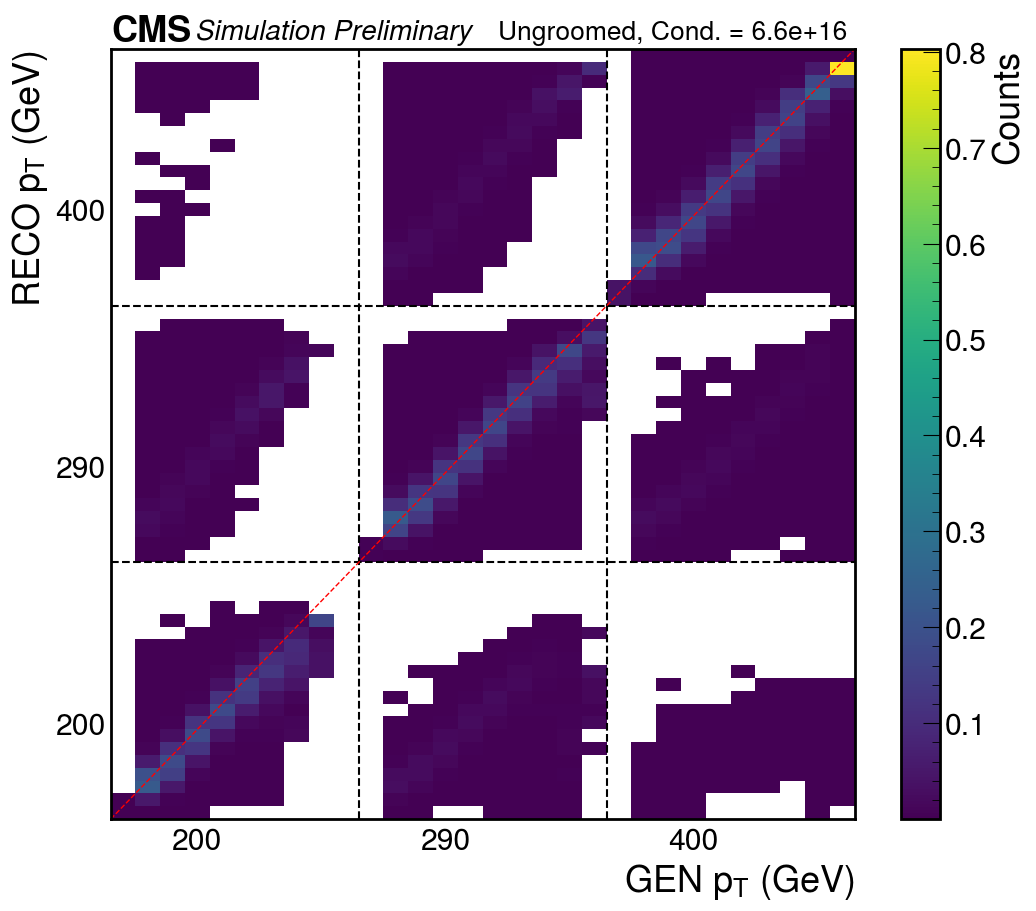

Warning in <TROOT::Append>: Replacing existing TH1: M (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_reco (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htrue (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htruef (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_corr (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2016 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2017 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2018 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteScaleUp_corr (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing 

In [200]:
unfolder.plot_response_matrix(probability_matrix=True)

In [189]:
unfolder.M_np.shape

(30, 60)

In [190]:
pt_sum = resp_matrix_4d[...,'nominal'].project('ptgen').values()

In [121]:
pt_sum = pt_sum/np.max(pt_sum)
1/pt_sum

array([1.        , 3.22558071, 7.93939854])

Working until background subtractions
Unfolder object created
Regularisation USED None
Tau value 0.0


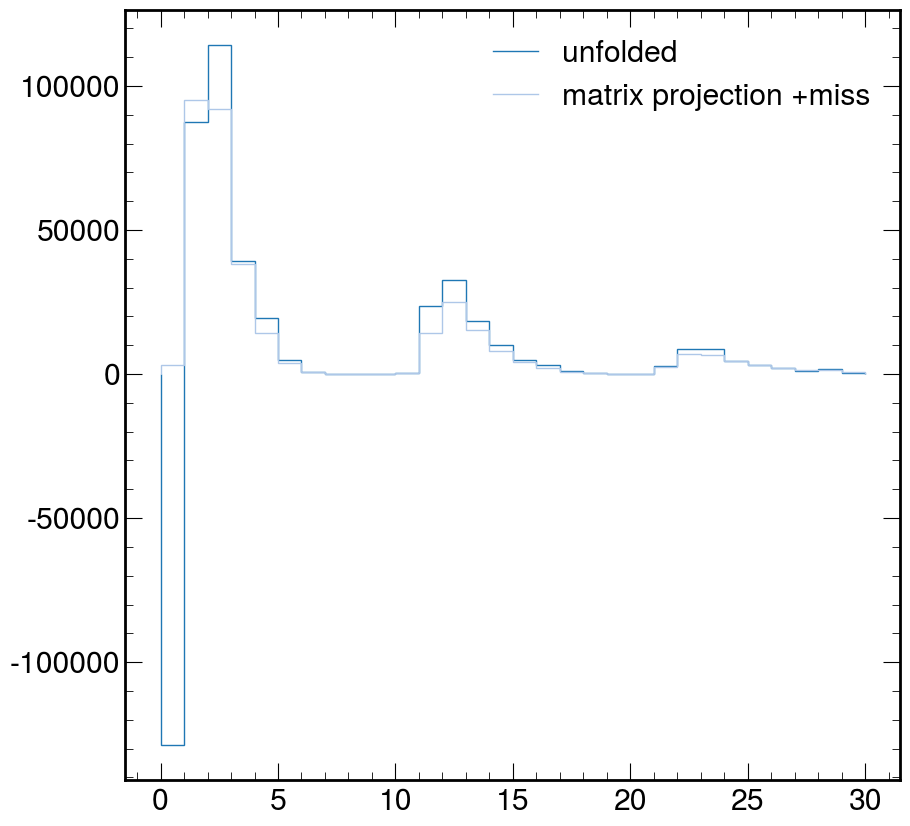

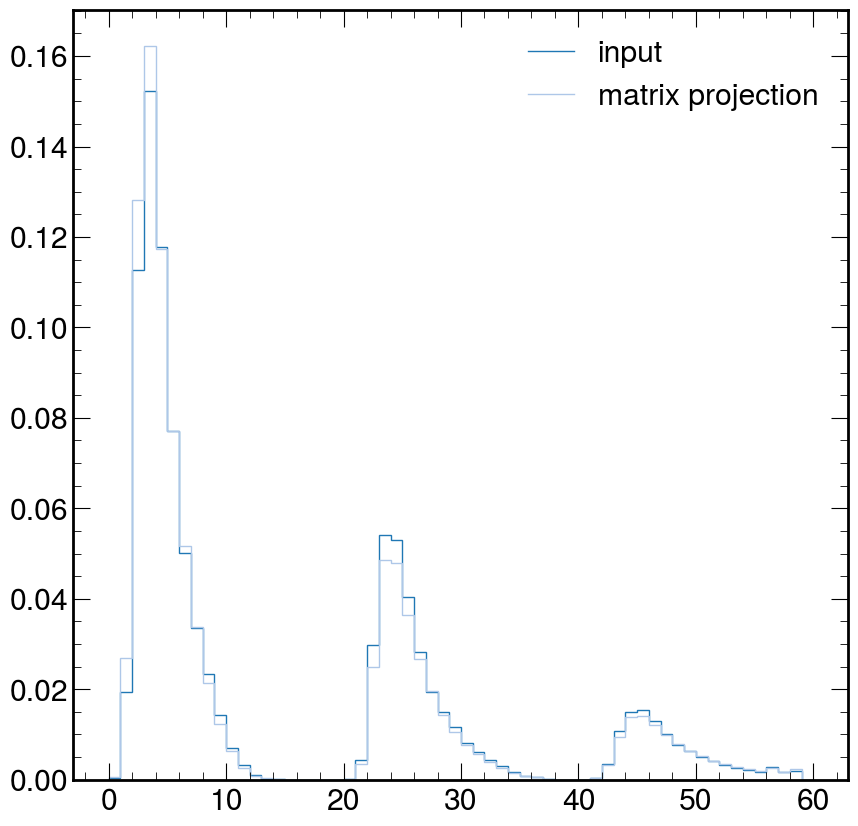

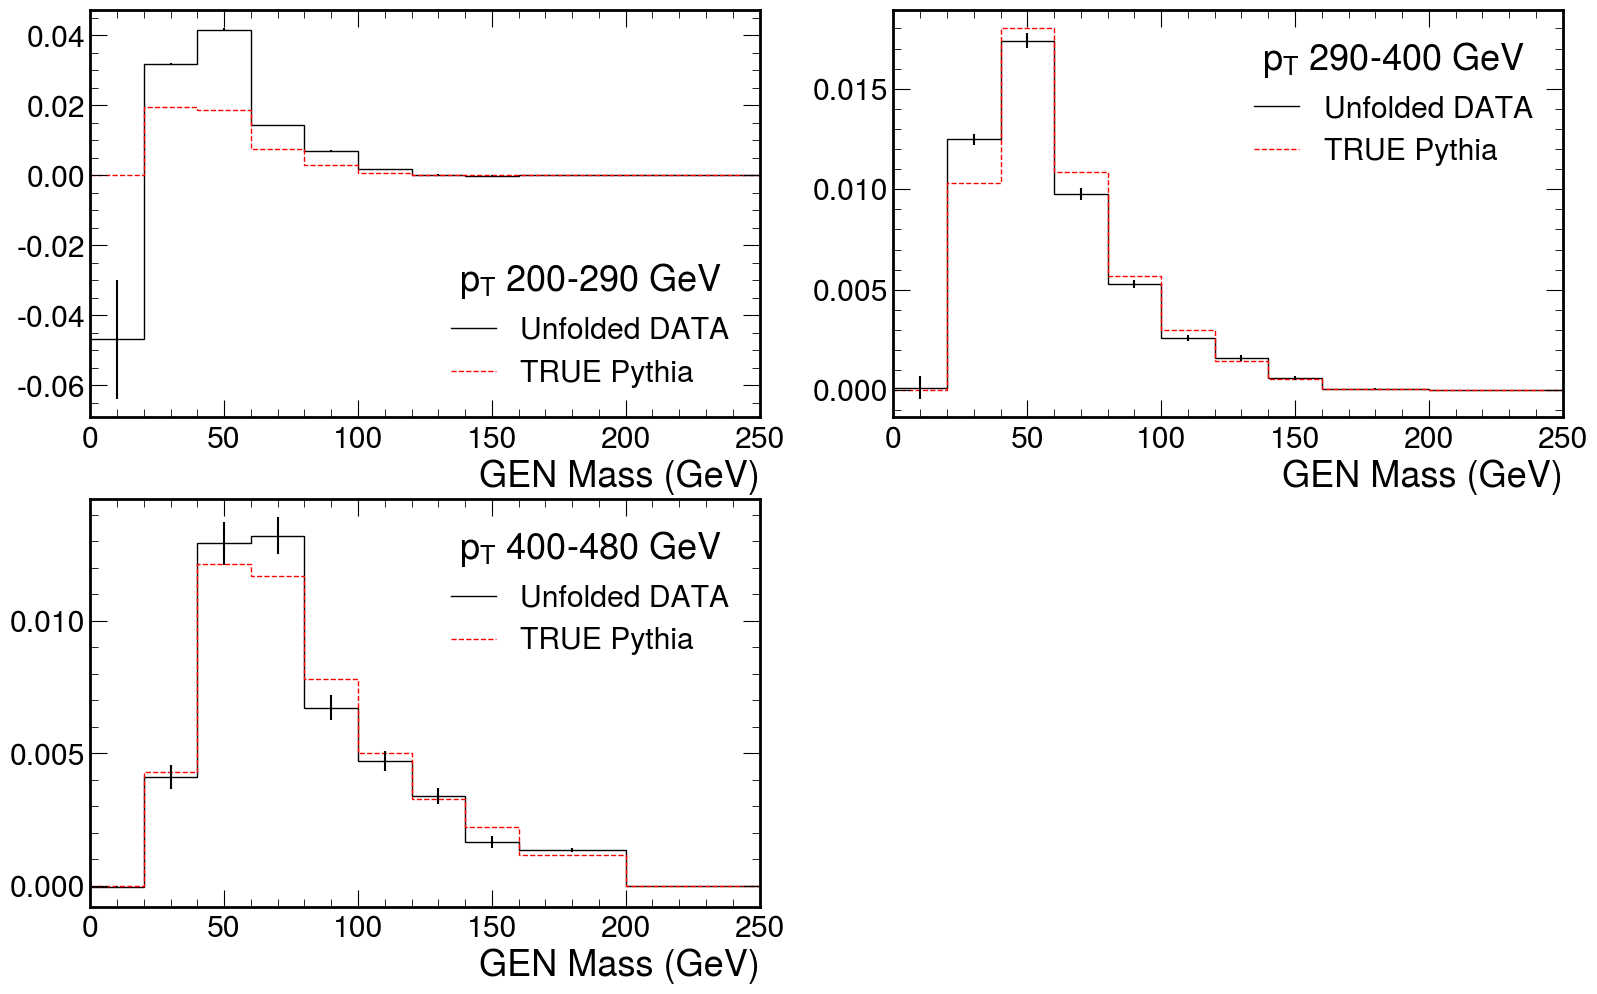

Warning in <TROOT::Append>: Replacing existing TH1: M (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_reco (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htrue (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htruef (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_corr (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2016 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2017 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2018 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteScaleUp_corr (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing 

In [201]:
unfolder.perform_unfold('None')

# Plot the covariance matrix or unfolded distributions:
#unfolder.plot_covariance()
unfolder.plot_unfolded()

<string>:27: RuntimeWarning: divide by zero encountered in divide
<string>:27: RuntimeWarning: invalid value encountered in divide
<string>:28: RuntimeWarning: divide by zero encountered in divide
<string>:28: RuntimeWarning: invalid value encountered in divide
<string>:29: RuntimeWarning: divide by zero encountered in divide
<string>:29: RuntimeWarning: invalid value encountered in divide
<string>:30: RuntimeWarning: divide by zero encountered in divide
<string>:30: RuntimeWarning: invalid value encountered in divide
<string>:31: RuntimeWarning: divide by zero encountered in divide
<string>:31: RuntimeWarning: invalid value encountered in divide


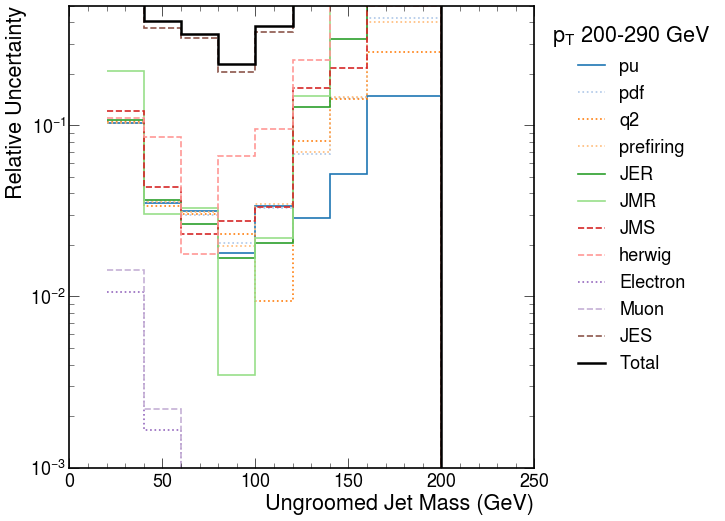

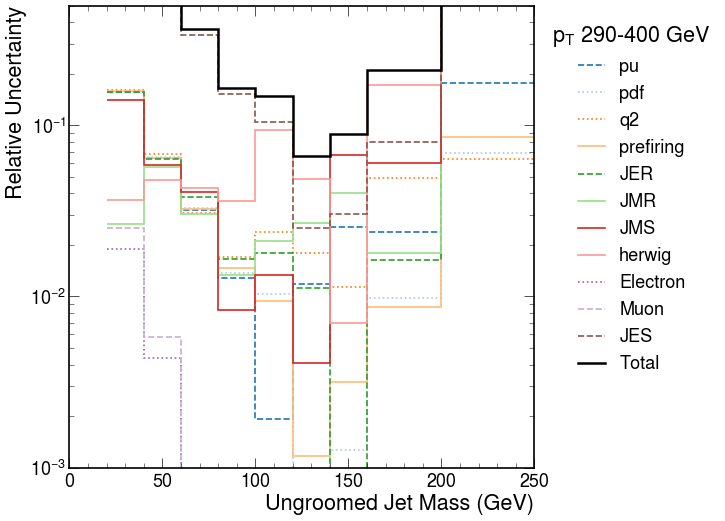

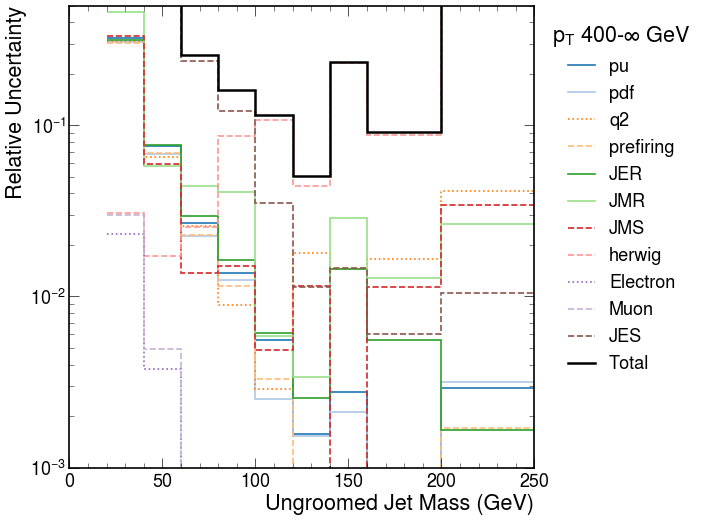

In [198]:
unfolder.plot_systematic_frac()

In [123]:
c = ROOT.TCanvas()

logSURE = unfolder.logSURE
logSURE.Draw()
c.Draw()

AttributeError: 'Unfolder' object has no attribute 'logSURE'

In [125]:
# regularized_output = unfolder.output_pt_binned_no_norm
# unfolder.plot_systematic_frac()
# regularized_unc = unfolder.total_sys

In [126]:
# plt.stairs(unfolder.total_sys)

In [127]:
# unfolder.perform_unfold('None')

# # Plot the covariance matrix or unfolded distributions:
# #unfolder.plot_covariance()
# unfolder.plot_unfolded()

In [128]:
# non_regularized_output = unfolder.output_pt_binned_no_norm
# unfolder.plot_systematic_frac()
# non_regularized_unc =  unfolder.total_sys

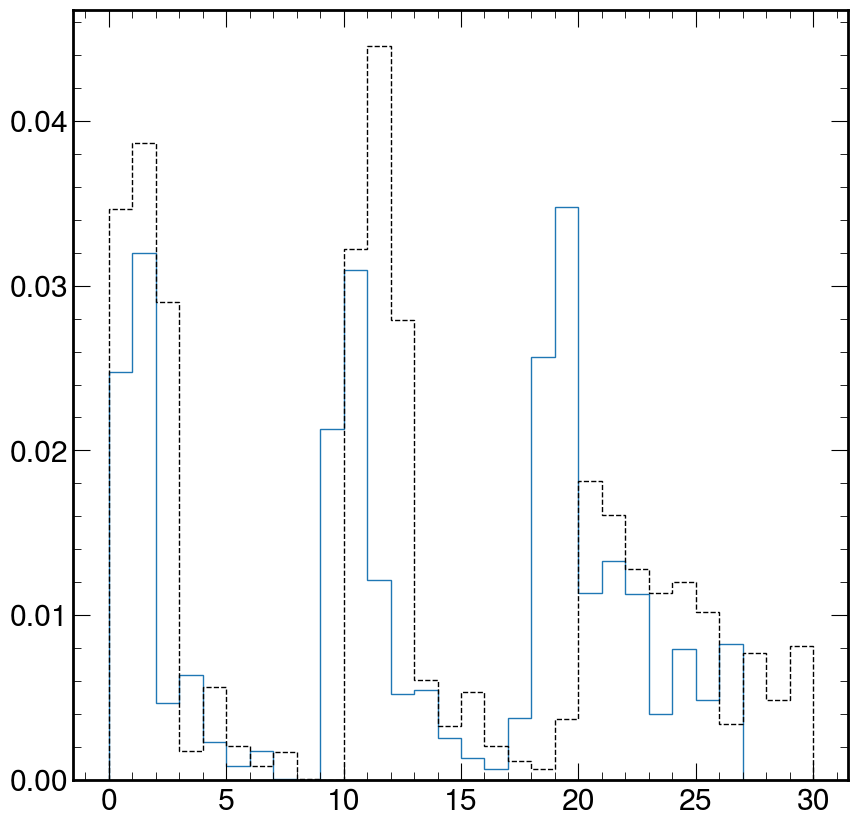

In [129]:
plt.stairs(regularized_unc)
plt.stairs(non_regularized_unc, ls = '--', color = 'k')

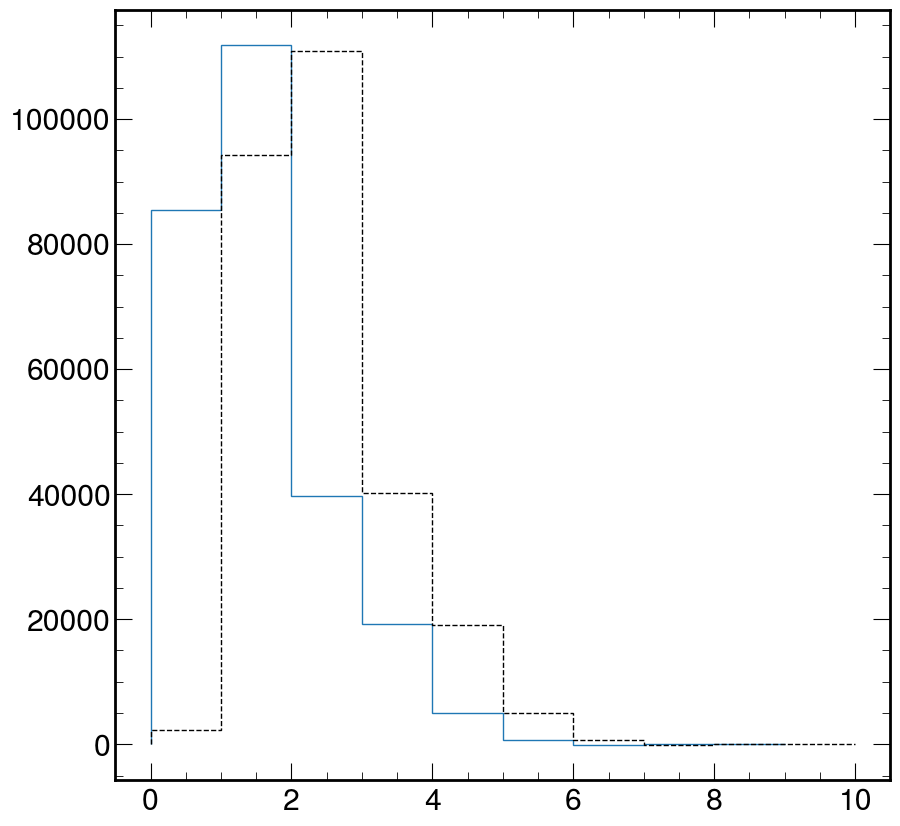

In [130]:
plt.stairs(regularized_output[0])
plt.stairs(non_regularized_output[0], ls = '--', color = 'k')

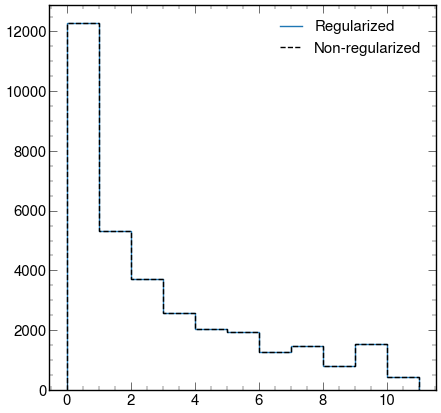

In [74]:
plt.stairs(regularized_output[2], label = 'Regularized', lw = 2)
plt.stairs(non_regularized_output[2], ls = '--', color = 'k' ,  label = 'Non-regularized', lw = 2)
plt.legend()

In [75]:
unfolder.stat_pt_binned

[array([755.0229919 , 645.73107942, 540.53938121, 528.64823857,
        563.03617125, 504.68955544, 435.25057056, 268.91279304,
        146.95509014, 122.18352117, 503.91982764]),
 array([417.42255621, 349.62706439, 280.82295884, 240.29983042,
        261.09826334, 299.52369661, 296.25004567, 273.30407187,
        200.36161563, 110.82963788, 146.02948001]),
 array([224.04921359, 199.96141755, 149.03238423, 123.94701585,
        124.6030633 , 141.91443488, 156.45064644, 162.37774912,
        136.40670006,  99.80839103,  35.8484013 ])]

In [76]:
u = unfolder.get_u()

L = u.GetL('l', 'l')

c = ROOT.TCanvas()

L.Draw('colz')
#c.SetLogz()
c.Draw()

(0.0, 0.2)

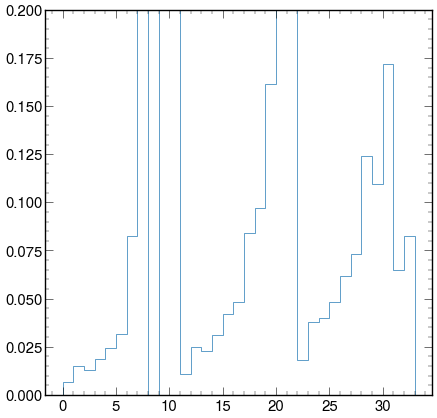

In [77]:
plt.stairs(unfolder.stat/unfolder.o_np)
plt.ylim(0,0.2)

In [78]:
o =u.GetOutput("o", "pythia", "signal",  "*[UOB]", False)
c = ROOT.TCanvas()
o.Draw()
c.Draw()

Warning in <TROOT::Append>: Replacing existing TH1: o (Potential memory leak).


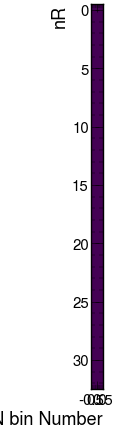

In [153]:
import ROOT
import numpy as np

# Assuming L is your TH2D object
nbinsX = L.GetNbinsX()
nbinsY = L.GetNbinsY()

array = np.zeros((nbinsX, nbinsY))

for i in range(1, nbinsX+1):
    for j in range(1, nbinsY+1):
        array[i-1, j-1] = L.GetBinContent(i, j)

L_np = array
plt.imshow(L_np , norm = 'symlog')
plt.xlabel('Global GEN bin Number')
plt.ylabel('nR')

htrue_np = unfolder.htrue_np
htrue_np_padded = np.concatenate(([0], htrue_np, [0]))




In [154]:
lx = u.GetLxMinusBias('Lx', 'Lx')


c = ROOT.TCanvas()

lx.Draw()
#c.SetLogz()
c.Draw()

In [133]:
unfolder.plot_systematic_frac()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.

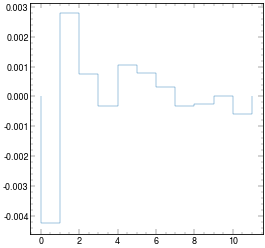

In [77]:
plt.stairs(unfolder.delta_sys_dic_pt_binned['JMRUp'][0])

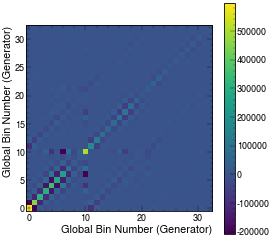

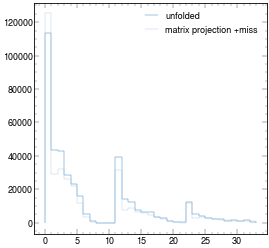

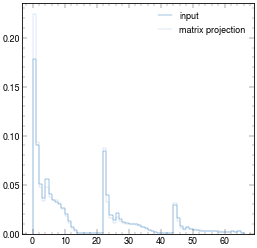

IndexError: list index out of range

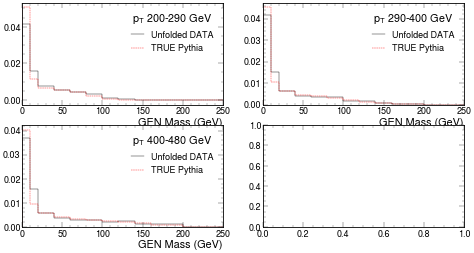

In [78]:


# Plot the covariance matrix or unfolded distributions:
unfolder.plot_covariance()
unfolder.plot_unfolded()

/tmp/ipykernel_655/2643699782.py:6: RuntimeWarning: invalid value encountered in divide
  hep.histplot(accepted[ipt]/(missed[ipt] + accepted[ipt]), mgen_edge, yerr = accepted_unc[ipt]/(missed[ipt] + accepted[ipt]), color = color_pt[ipt], label = title_list[ipt])


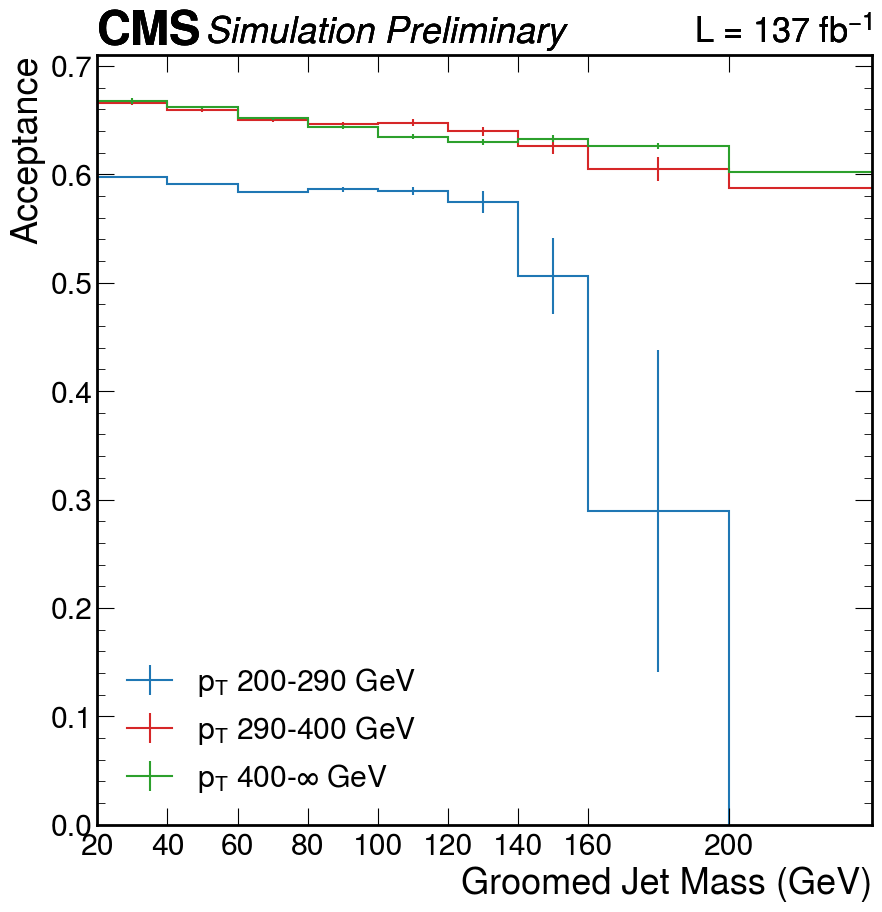

In [134]:

accepted = resp_matrix_4d[{'systematic':'nominal'}].project('ptgen', 'mgen').values()
missed = misses.project('ptgen', 'mgen').values()
accepted_unc =resp_matrix_4d[{'systematic':'nominal'}].project('ptgen', 'mgen').variances()**0.5
#mgen_edge[-1] = 240
for ipt in range(len(pt_edges)-1):
    hep.histplot(accepted[ipt]/(missed[ipt] + accepted[ipt]), mgen_edge, yerr = accepted_unc[ipt]/(missed[ipt] + accepted[ipt]), color = color_pt[ipt], label = title_list[ipt])
    # Set x-ticks to bin edges
    xtick_labels = [str(int(tick)) for tick in mgen_edge]  # Convert to string
    xtick_labels[-1] = r"$\infty$"  # Replace last label with infinity
    plt.tick_params(axis='x', which='minor', top=False, bottom=False)

    plt.xticks(mgen_edge, xtick_labels)
    
    plt.legend()

    if not groomed:
        plt.xlim(20,241)
        plt.xlabel("Groomed Jet Mass (GeV)")
    else:
        plt.xlim(10, 241)
        plt.xlabel("Ungroomed Jet Mass (GeV)")
    plt.ylabel("Acceptance")
    hep.cms.label("Preliminary", rlabel = r'L = 137 $fb^{-1}$')

/tmp/ipykernel_655/965594280.py:8: RuntimeWarning: invalid value encountered in divide
  hep.histplot(faked[ipt]/(faked[ipt] + accepted_reco[ipt]), mreco_edge, yerr = faked_unc[ipt]/(faked[ipt] + accepted_reco[ipt]), color = color_pt[ipt], label = title_list[ipt])
/tmp/ipykernel_655/965594280.py:8: RuntimeWarning: invalid value encountered in divide
  hep.histplot(faked[ipt]/(faked[ipt] + accepted_reco[ipt]), mreco_edge, yerr = faked_unc[ipt]/(faked[ipt] + accepted_reco[ipt]), color = color_pt[ipt], label = title_list[ipt])


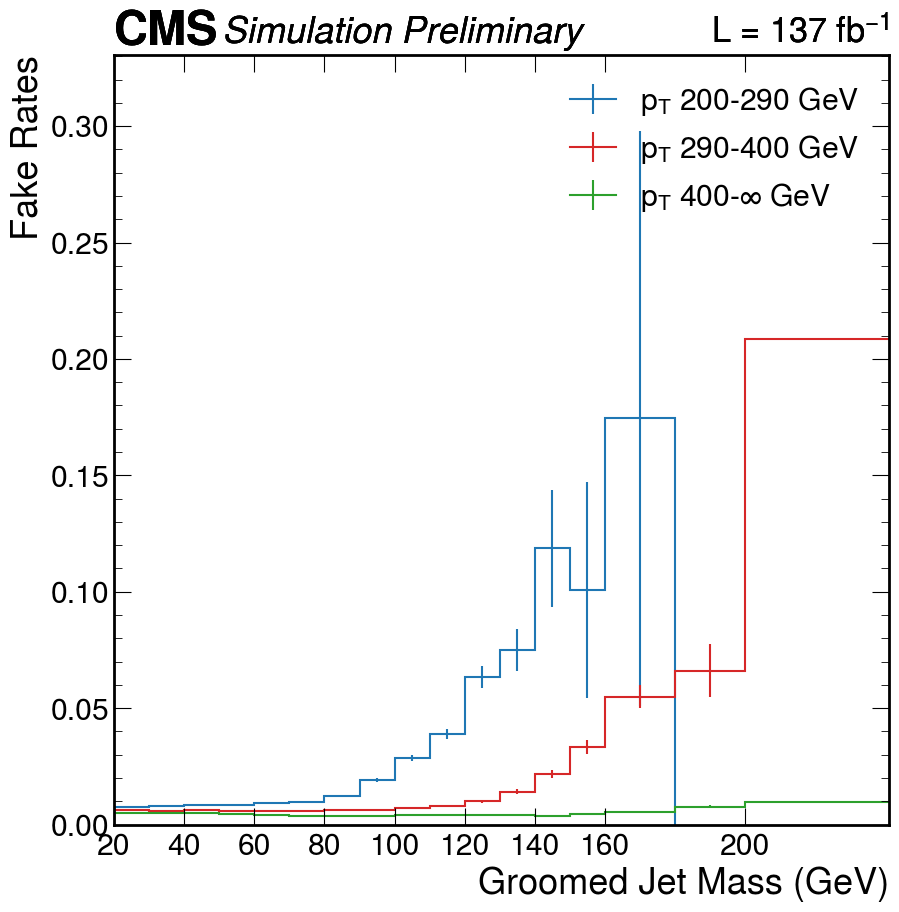

In [135]:

accepted_reco = resp_matrix_4d[{'systematic':'nominal'}].project('ptreco', 'mreco').values()
faked = fakes.project('ptreco', 'mreco').values()
faked_unc =  fakes.project('ptreco', 'mreco').variances()**0.5
# mreco_edge[-2] = 220
# mreco_edge[-1] = 240

for ipt in range(npt):
    hep.histplot(faked[ipt]/(faked[ipt] + accepted_reco[ipt]), mreco_edge, yerr = faked_unc[ipt]/(faked[ipt] + accepted_reco[ipt]), color = color_pt[ipt], label = title_list[ipt])
    # Set x-ticks to bin edges
    xtick_labels = [str(int(tick)) for tick in mgen_edge]  # Convert to string
    xtick_labels[-1] = r"$\infty$"  # Replace last label with infinity
    plt.tick_params(axis='x', which='minor', top=False, bottom=False)

    plt.xticks(mgen_edge, xtick_labels)
    
    plt.legend()

    if not groomed:
        plt.xlim(20,241)
        plt.xlabel("Groomed Jet Mass (GeV)")
    else:
        plt.xlim(10, 241)
        plt.xlabel("Ungroomed Jet Mass (GeV)")
    plt.ylabel("Fake Rates")
    hep.cms.label("Preliminary", rlabel = r'L = 137 $fb^{-1}$')

In [81]:
mreco_edge

array([0.0e+00, 5.0e+00, 1.0e+01, 1.5e+01, 2.0e+01, 3.0e+01, 4.0e+01,
       5.0e+01, 6.0e+01, 7.0e+01, 8.0e+01, 9.0e+01, 1.0e+02, 1.1e+02,
       1.2e+02, 1.3e+02, 1.4e+02, 1.5e+02, 1.6e+02, 1.8e+02, 2.0e+02,
       5.0e+02, 1.3e+04])

/tmp/ipykernel_655/466694296.py:2: RuntimeWarning: invalid value encountered in divide
  hep.histplot( 1 - (faked[ipt]/(faked[ipt] + accepted_reco[ipt])), mreco_edge, yerr = faked_unc[ipt]/(faked[ipt] + accepted_reco[ipt]), color = 'b', label = '1 - Fake Rates')
/tmp/ipykernel_655/466694296.py:3: RuntimeWarning: invalid value encountered in divide
  hep.histplot(accepted[ipt]/(missed[ipt] + accepted[ipt]), mgen_edge, yerr = accepted_unc[ipt]/(missed[ipt] + accepted[ipt]), color = 'r', label = 'Acceptance')


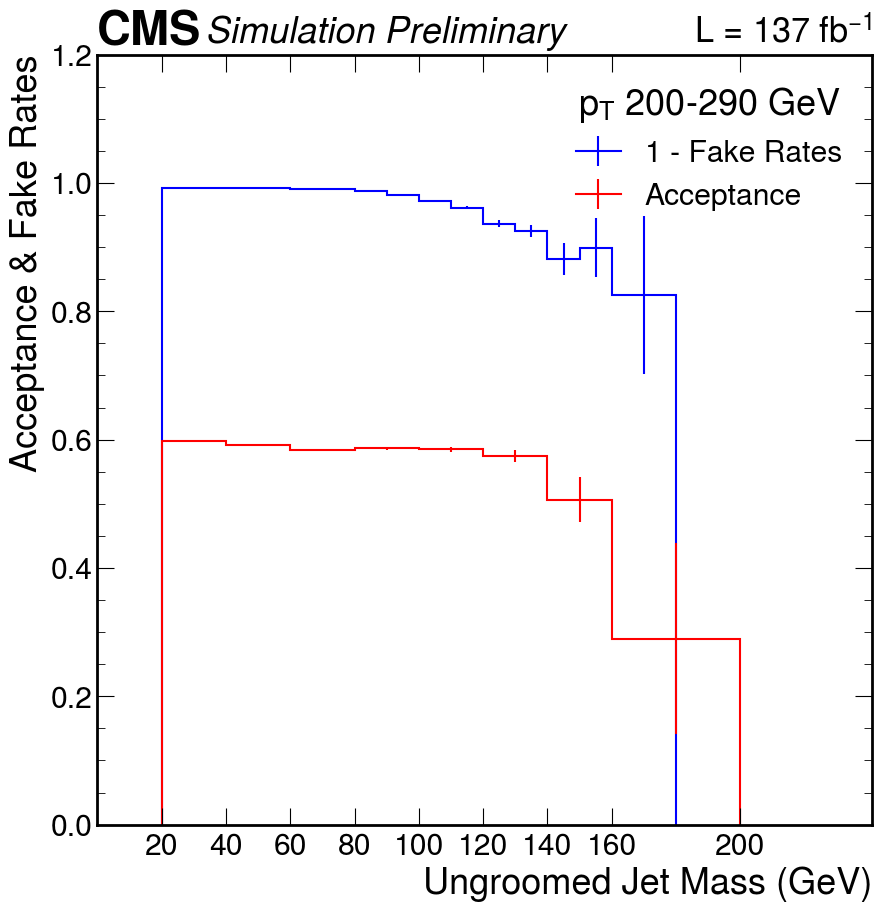

/tmp/ipykernel_655/466694296.py:2: RuntimeWarning: invalid value encountered in divide
  hep.histplot( 1 - (faked[ipt]/(faked[ipt] + accepted_reco[ipt])), mreco_edge, yerr = faked_unc[ipt]/(faked[ipt] + accepted_reco[ipt]), color = 'b', label = '1 - Fake Rates')


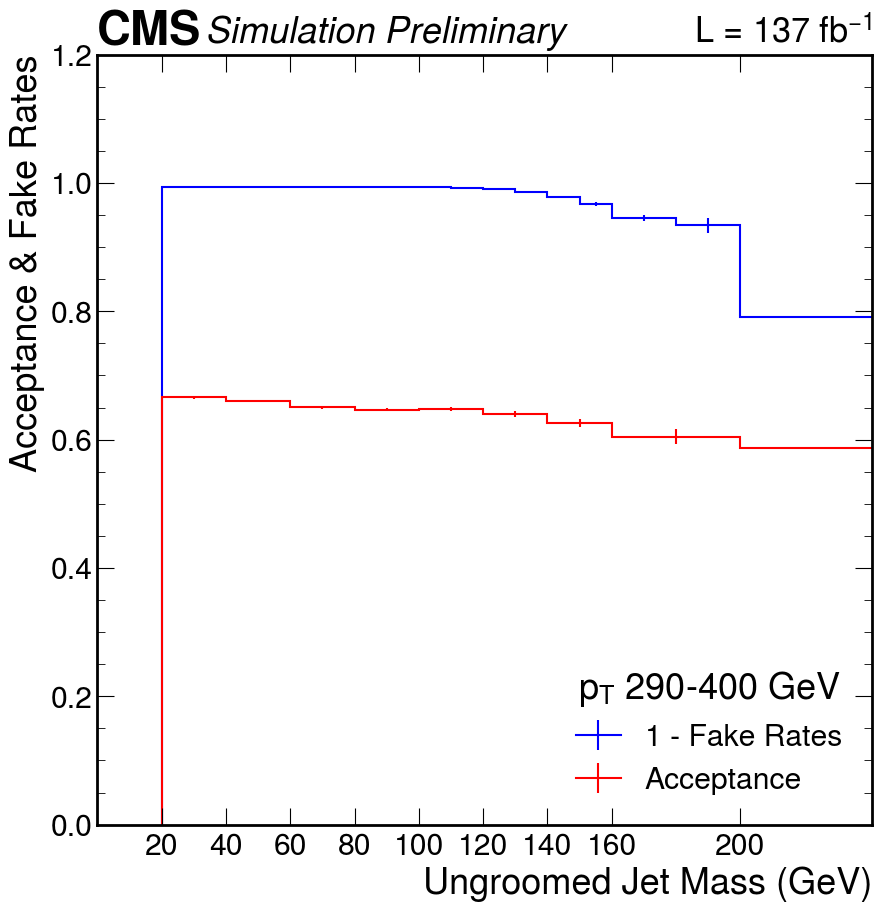

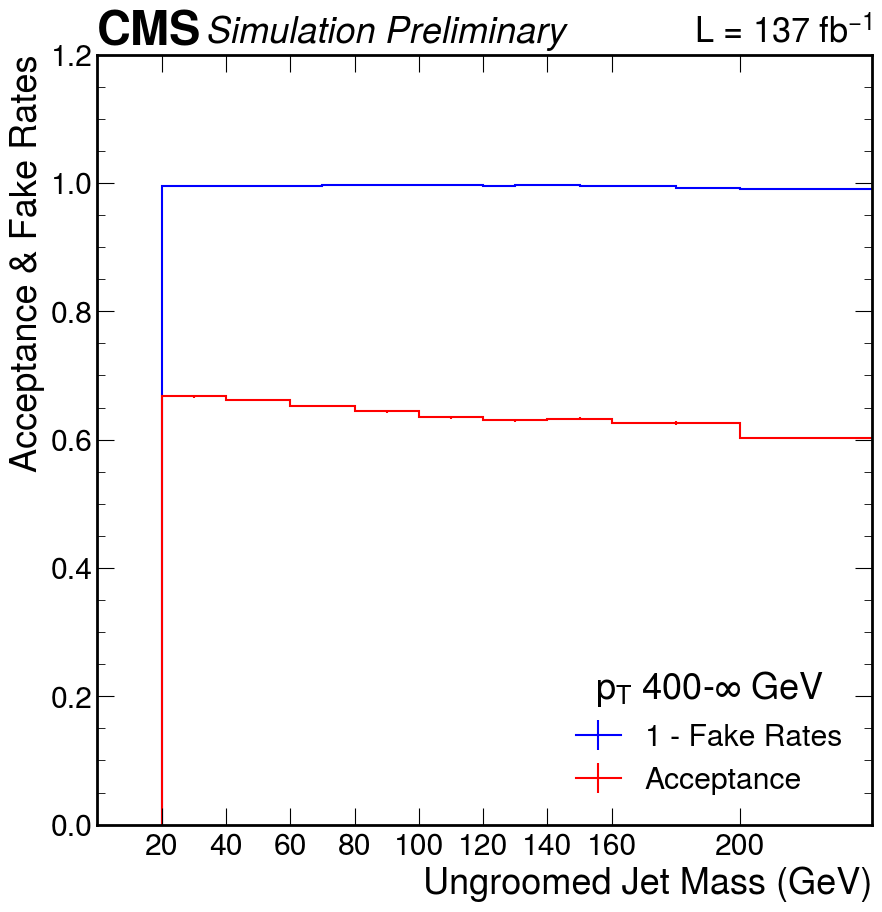

In [136]:
for ipt in range(npt):
    hep.histplot( 1 - (faked[ipt]/(faked[ipt] + accepted_reco[ipt])), mreco_edge, yerr = faked_unc[ipt]/(faked[ipt] + accepted_reco[ipt]), color = 'b', label = '1 - Fake Rates')
    hep.histplot(accepted[ipt]/(missed[ipt] + accepted[ipt]), mgen_edge, yerr = accepted_unc[ipt]/(missed[ipt] + accepted[ipt]), color = 'r', label = 'Acceptance')

    xtick_labels = [str(int(tick)) for tick in mgen_edge]  # Convert to string
    xtick_labels[-1] = r"$\infty$"  # Replace last label with infinity
    plt.tick_params(axis='x', which='minor', top=False, bottom=False)

    plt.xticks(mgen_edge, xtick_labels)
    
    plt.legend(title = title_list[ipt])
    if not groomed:
        plt.xlim(0,241)
        plt.xlabel("Ungroomed Jet Mass (GeV)")
    else:
        plt.xlim(0, 241)
        plt.xlabel("Groomed Jet Mass (GeV)")
    plt.ylabel("Acceptance & Fake Rates")
    plt.ylim(0, 1.2)
    hep.cms.label("Preliminary", rlabel = r'L = 137 $fb^{-1}$')
    
    if groomed:
        plt.savefig(f'plots/fakerates_groomed_{ipt}.pdf')
    else:
        plt.savefig(f'plots/fakerates_ungroomed_{ipt}.pdf')

    plt.show()

In [137]:
# for ipt in range(4):
#     hep.histplot(resp_matrix_4d[{'systematic':'nominal'}].project('ptgen', 'ptreco', 'mreco')[hist.underflow, : , :][ipt,:].values()/(accepted[ipt]), mreco_edge, color = color_pt[ipt], label = title_list[ipt])
#     xtick_labels = [str(int(tick)) for tick in mgen_edge]  # Convert to string
#     xtick_labels[-1] = r"$\infty$"  # Replace last label with infinity
#     plt.tick_params(axis='x', which='minor', top=False, bottom=False)

#     plt.xticks(mgen_edge, xtick_labels)
    
#     plt.legend(fontsize = 20)

#     if not groomed:
#         plt.xlim(20,241)
#         plt.xlabel("Groomed Jet Mass (GeV)")
#     else:
#         plt.xlim(10, 241)
#         plt.xlabel("Ungroomed Jet Mass (GeV)")
#     plt.ylabel("Fake Rates Due to Underflow")
#     hep.cms.label("Preliminary", rlabel = r'L = 137 $fb^{-1}$')

In [138]:
# m3 = resp_matrix_4d[{'systematic':'nominal'}].project('ptgen', 'mgen', 'ptreco', 'mreco')[:,:, sum, hist.rebin(2)].values()
# plt.figure(figsize = (20, 20))
# for ipt in range(4):
#     m30 = m3[ipt]
#     plt.subplot(2, 2, ipt+1)
    
#     hep.histplot(np.diag(m3[ipt])/m3[ipt].sum(axis = 1),mgen_edge, label = 'Stability')
#     hep.histplot(np.diag(m3[ipt])/m3[ipt].sum(axis = 0),mgen_edge, label = 'Purity', color = 'r')
#     plt.xlim(20,250)
#     plt.xlabel("Ungroomed Jet Mass (GeV)")
#     plt.ylabel("Fraction")
#     plt.legend(title = title_list[ipt])
#     xtick_labels = [str(int(tick)) for tick in mgen_edge]  # Convert to string
#     xtick_labels[-1] = r"$\infty$"  # Replace last label with infinity
#     plt.tick_params(axis='x', which='minor', top=False, bottom=False)

#     plt.xticks(mgen_edge, xtick_labels)
#     #plt.show()

In [139]:
unfolder_dn = Unfolder(input_data, 
                    resp_matrix_4d[{'systematic':'nominal'}] ,
                    #resp_matrix_4d_jk,
                    fakes = fakes,
                    misses = misses,
                    backgrounds = {"ww": ww_bg, "wz":wz_bg, "zz": zz_bg},
                    #systematics = {'JES_AbsoluteMPFBiasUp': resp_matrix_4d[{'systematic':'JES_AbsoluteMPFBiasUp'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()  },
                    systematics = sys_matrix_dic_down,
                    #systematics= None,
                    #systematics = jes_sys_list_up,
                    closure = False,
                    groomed = groomed,
                    is_uf = True,
                    merge = False,
                    normalised_xs = True,
                    normalized_syst = True,
                    do_syst = True,
                    discard_low_bins = False,
                    regularisation= 'None',
                    do_norm = False
                           )

9
[   20.    40.    60.    80.   100.   120.   140.   160.   200. 13000.]
18
[   20.    30.    40.    50.    60.    70.    80.    90.   100.   110.
   120.   130.   140.   150.   160.   180.   200.   500. 13000.]
Detector Binning created
shape of you (54,)


<string>:9: RuntimeWarning: invalid value encountered in divide
<string>:35: RuntimeWarning: invalid value encountered in divide


Working until background subtractions
Unfolder object created
Condition number of the matrix  1.439429284772524e+17


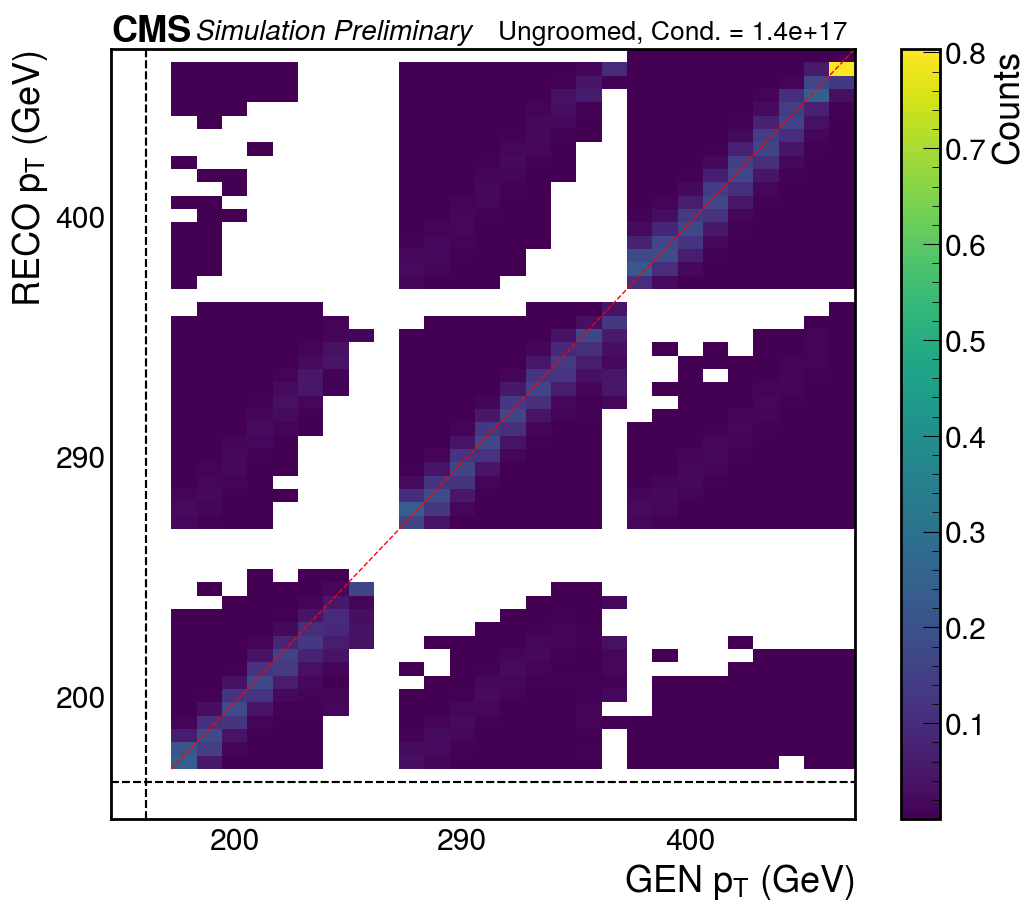

Warning in <TROOT::Append>: Replacing existing TH1: M (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_reco (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htrue (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htruef (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_corr (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2016 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2017 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteMPFBiasUp_uncorr_2018 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: MJES_AbsoluteScaleUp_corr (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing 

In [140]:
unfolder.plot_response_matrix(probability_matrix=True)


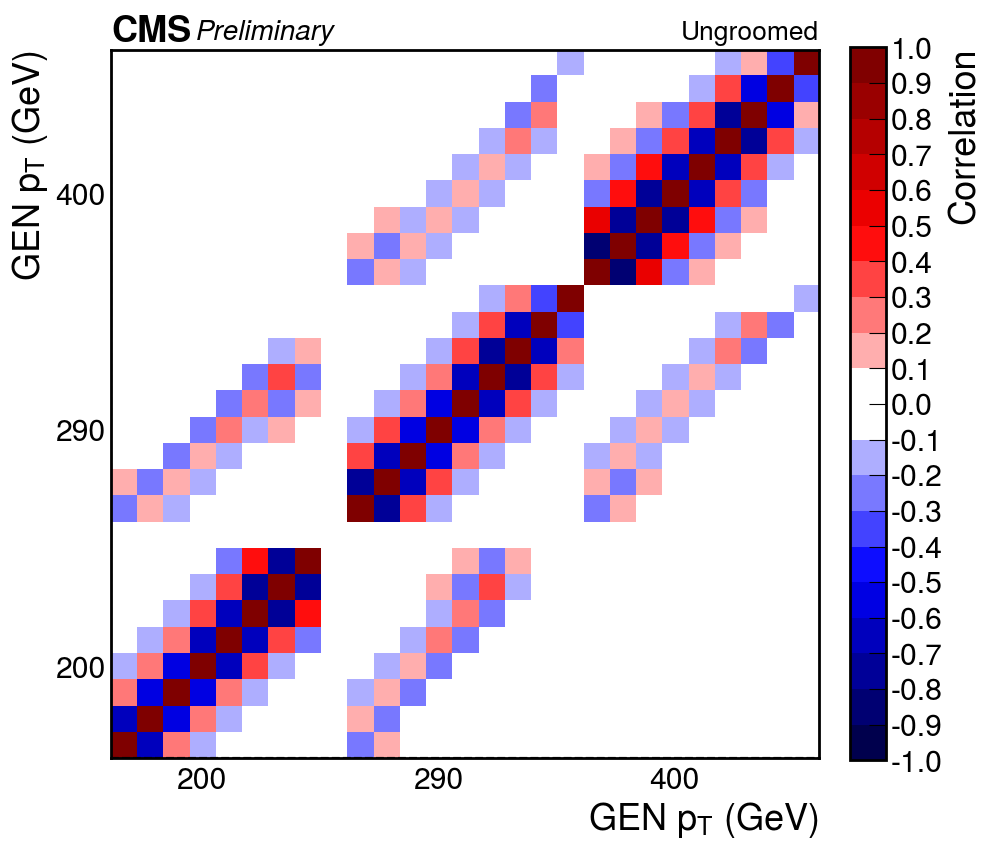

In [141]:
ax = unfolder.plot_correlation()
if groomed:
    hep.cms.label("Preliminary" , fontsize = 20, data = True, ax = ax, rlabel = "Groomed")
else:
    hep.cms.label("Preliminary" , fontsize = 20, data = True, ax = ax, rlabel = "Ungroomed")

Working until background subtractions
Unfolder object created
Regularisation USED None
Tau value 0.0


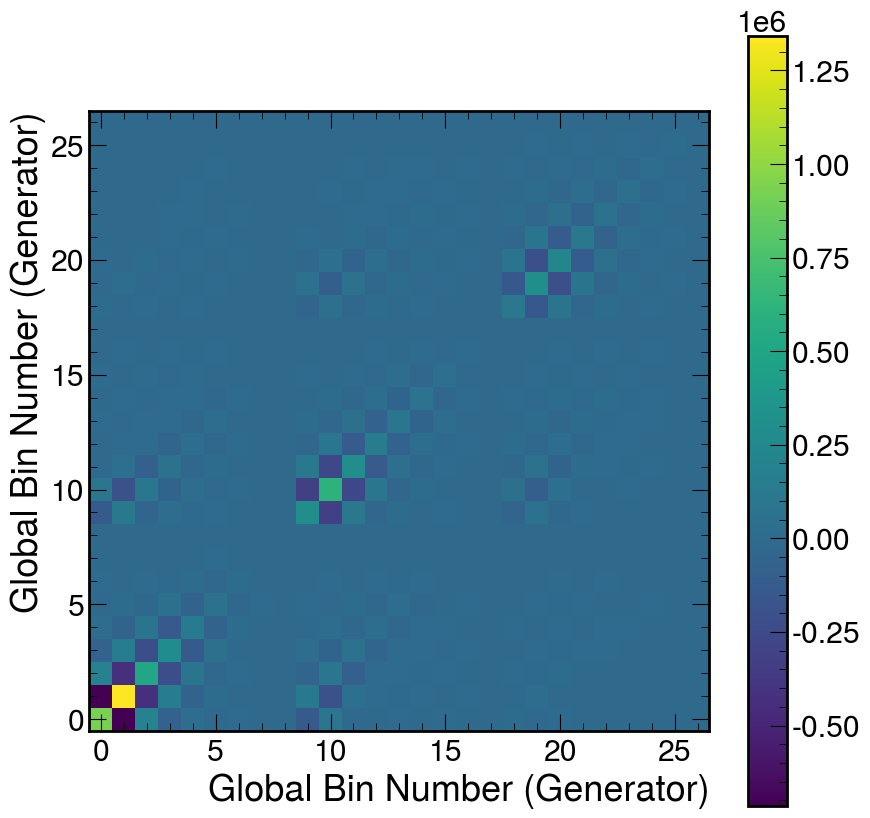

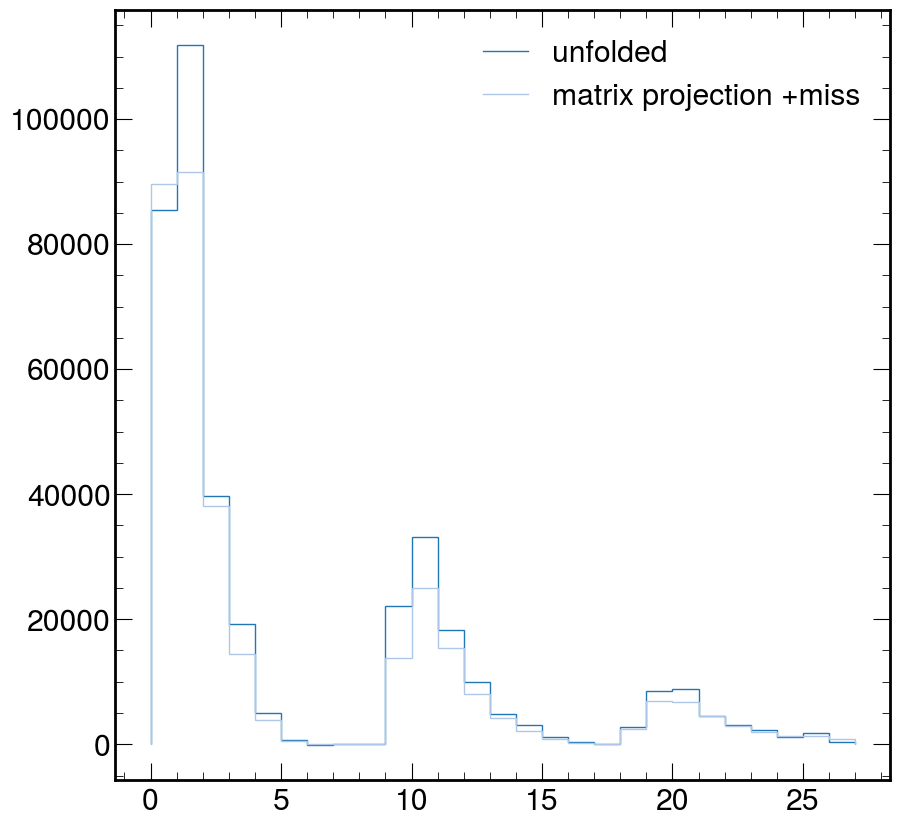

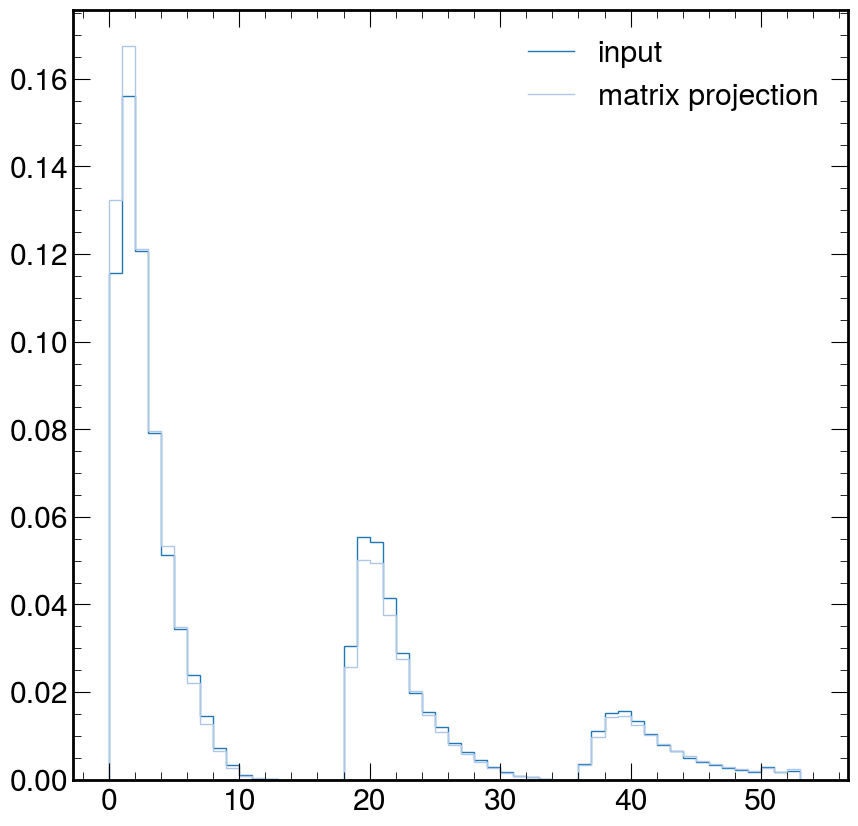

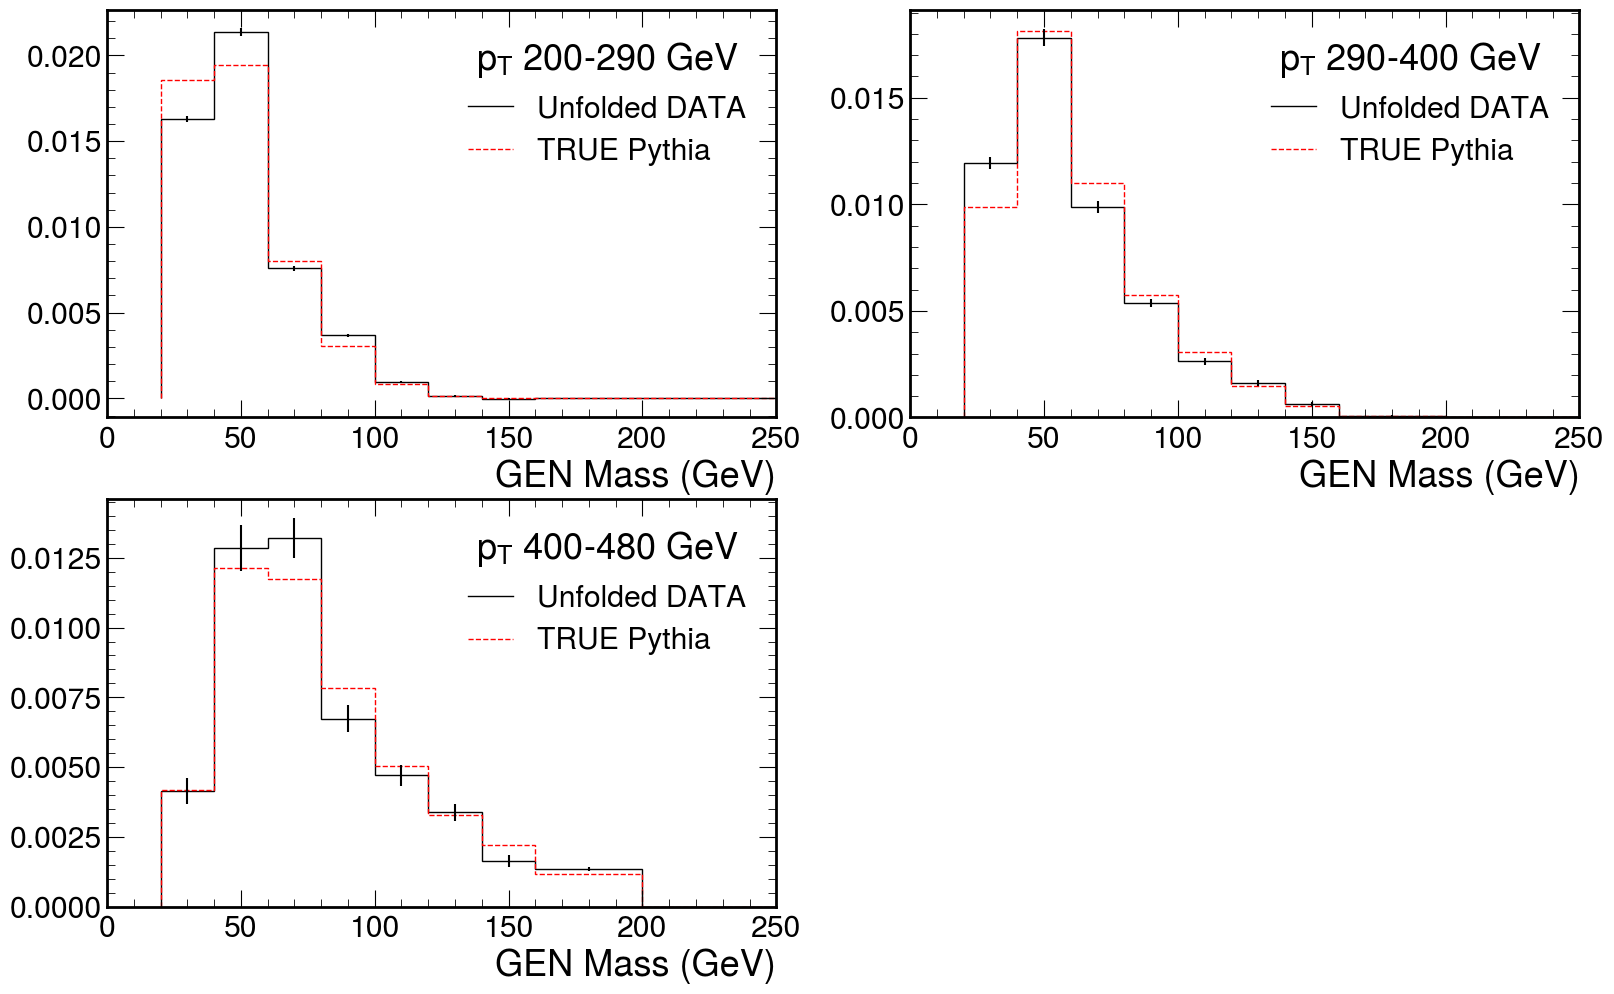

Warning in <TROOT::Append>: Replacing existing TH1: M (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_reco (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htrue (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htruef (Potential memory leak).
Info in <TUnfold::SetConstraint>: fConstraint=1
Warning in <TUnfold::TUnfold>: 3 output bins do not depend on the input data  0 9 28
Info in <TUnfold::TUnfold>: 54 input bins and 26 output bins
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #0
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #9 (signal:ptgen[200,290]:massgen[200,300])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #28
Info in <TUnfoldDensity::RegularizeOneDistribution>: regularizing signal regMode=2 densityMode=3 axisSteering=*[UOB]
Warning in <TUnfoldDensity::SetInput>: 5/54 input bins have zero

In [142]:
unfolder_dn.perform_unfold()

# Plot the covariance matrix or unfolded distributions:
unfolder_dn.plot_covariance()
unfolder_dn.plot_unfolded()

/tmp/ipykernel_845/143461075.py:3: RuntimeWarning: invalid value encountered in divide
  plt.stairs(np.abs(unfolder_dn.output_pt_binned[0]-unfolder_dn.o_sys_dic_pt_binned['JMRDown'][0])/unfolder_dn.output_pt_binned[0])
/tmp/ipykernel_845/143461075.py:4: RuntimeWarning: invalid value encountered in divide
  plt.stairs(np.abs(unfolder.output_pt_binned[0]-unfolder.o_sys_dic_pt_binned['JMRUp'][0])/unfolder.output_pt_binned[0])


(0.0, 0.1)

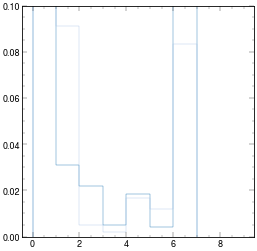

In [50]:
# plt.stairs(unfolder_dn.o_sys_dic_pt_binned['JMRDown'][0])
# plt.stairs(unfolder_dn.output_pt_binned[0])
plt.stairs(np.abs(unfolder_dn.output_pt_binned[0]-unfolder_dn.o_sys_dic_pt_binned['JMRDown'][0])/unfolder_dn.output_pt_binned[0])
plt.stairs(np.abs(unfolder.output_pt_binned[0]-unfolder.o_sys_dic_pt_binned['JMRUp'][0])/unfolder.output_pt_binned[0])

plt.ylim(0, 0.1)

In [87]:
unfolder_dn.plot_output_sys()

NameError: name 'title_list' is not defined

In [88]:
plt.rcParams['figure.dpi'] = 20

In [195]:
unfolder.plot_systematic_frac()

AttributeError: 'Unfolder' object has no attribute 'o_np'

In [194]:
unfolder.plot_systematic_frac()

AttributeError: 'Unfolder' object has no attribute 'o_np'

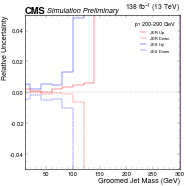

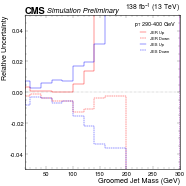

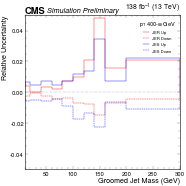

In [90]:
sys = 'JER'
sys2 = 'JES'
#sys3 = 'eletrig'
for ipt in range(npt):
    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][1], label = sys+' Up' , color = 'r' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][1], label = sys+' Down'  , ls = '--', color = 'r')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][1], label = sys2+' Up' , color ='b' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][1], label = sys2+' Down'  , ls = '--', color ='b')

    #hep.histplot(unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0],unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Up' , color = 'g')
    #hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Down'  , ls = '--', color = 'g')
    
    plt.hlines(0, 0, 300, color = 'k' , ls = '-.', alpha = 0.3)
    plt.legend(title = title_list[ipt], fontsize = 15, title_fontsize = 20)
    #plt.ylim(-0.1,0.1)
    if groomed:
        plt.xlabel("Groomed Jet Mass (GeV)")
        plt.xlim(10,300)
    else:
        plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.xlim(20,300)
    plt.ylabel("Relative Uncertainty")
    #plt.yscale('symlog')
    plt.ylim(-0.05, 0.05)
    #plt.yscale('symlog')
    hep.cms.label('Preliminary', rlabel = r"138 $fb^{-1}$ (13 TeV)")
    if groomed:
        plt.savefig(f'plots/uncertainties/{sys}_groomed_{ipt}.pdf', dpi = 300)
    else:
        plt.savefig(f'plots/uncertainties/{sys}_ungroomed_{ipt}.pdf', dpi = 300)
        
    
    plt.show()

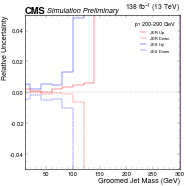

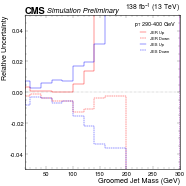

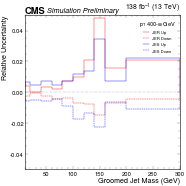

In [91]:
sys = 'JER'
sys2 = 'JES'
#sys3 = 'eletrig'
for ipt in range(npt):
    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][1], label = sys+' Up' , color = 'r' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][1], label = sys+' Down'  , ls = '--', color = 'r')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][1], label = sys2+' Up' , color ='b' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][1], label = sys2+' Down'  , ls = '--', color ='b')

    #hep.histplot(unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0],unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Up' , color = 'g')
    #hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Down'  , ls = '--', color = 'g')
    
    plt.hlines(0, 0, 300, color = 'k' , ls = '-.', alpha = 0.3)
    plt.legend(title = title_list[ipt], fontsize = 15, title_fontsize = 20)
    #plt.ylim(-0.1,0.1)
    if groomed:
        plt.xlabel("Groomed Jet Mass (GeV)")
        plt.xlim(10,300)
    else:
        plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.xlim(20,300)
    plt.ylabel("Relative Uncertainty")
    #plt.yscale('symlog')
    plt.ylim(-0.05, 0.05)
    #plt.yscale('symlog')
    hep.cms.label('Preliminary', rlabel = r"138 $fb^{-1}$ (13 TeV)")
    if groomed:
        plt.savefig(f'plots/uncertainties/{sys}_groomed_{ipt}.pdf', dpi = 300)
    else:
        plt.savefig(f'plots/uncertainties/{sys}_ungroomed_{ipt}.pdf', dpi = 300)
        
    
    plt.show()

In [92]:
unfolder.plot_systematic_frac(sys_list = ['total'])[ipt][0]

array([0.02634913, 0.06774859, 0.02542704, 0.01635397, 0.01566415,
       0.06747197, 0.0619181 , 0.07539085, 0.2445631 , 0.05279319,
       0.44273569])

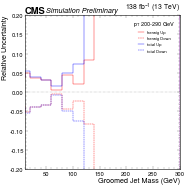

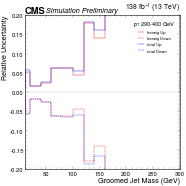

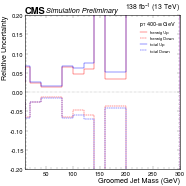

In [93]:
sys = 'herwig'
sys2 = 'total'
#sys3 = 'eletrig'
for ipt in range(npt):
    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][1], label = sys+' Up' , color = 'r' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][1], label = sys+' Down'  , ls = '--', color = 'r')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys2])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys2])[ipt][1], label = sys2+' Up' , color ='b' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys2])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys2])[ipt][1], label = sys2+' Down'  , ls = '--', color ='b')

    #hep.histplot(unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0],unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Up' , color = 'g')
    #hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Down'  , ls = '--', color = 'g')
    
    plt.hlines(0, 0, 300, color = 'k' , ls = '-.', alpha = 0.3)
    plt.legend(title = title_list[ipt], fontsize = 15, title_fontsize = 20)
    #plt.ylim(-0.1,0.1)
    if groomed:
        plt.xlabel("Groomed Jet Mass (GeV)")
        plt.xlim(10,300)
    else:
        plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.xlim(20,300)
    plt.ylabel("Relative Uncertainty")
    #plt.yscale('symlog')
    plt.ylim(-0.2, 0.2)
    #plt.yscale('symlog')
    hep.cms.label('Preliminary', rlabel = r"138 $fb^{-1}$ (13 TeV)")
    if groomed:
        plt.savefig(f'plots/uncertainties/{sys}_groomed_{ipt}.pdf', dpi = 300)
    else:
        plt.savefig(f'plots/uncertainties/{sys}_ungroomed_{ipt}.pdf', dpi = 300)
        
    
    plt.show()

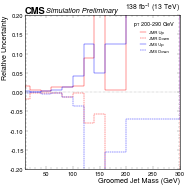

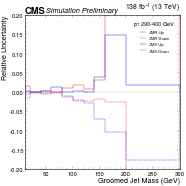

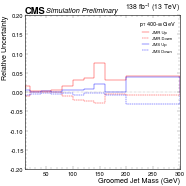

In [94]:
sys = 'JMR'
sys2 = 'JMS'
#sys3 = 'eletrig'
for ipt in range(npt):
    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][1], label = sys+' Up' , color = 'r' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][1], label = sys+' Down'  , ls = '--', color = 'r')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][1], label = sys2+' Up' , color ='b' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][1], label = sys2+' Down'  , ls = '--', color ='b')

    #hep.histplot(unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0],unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Up' , color = 'g')
    #hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Down'  , ls = '--', color = 'g')
    
    plt.hlines(0, 0, 300, color = 'k' , ls = '-.', alpha = 0.3)
    plt.legend(title = title_list[ipt], fontsize = 15, title_fontsize = 20)
    #plt.ylim(-0.1,0.1)
    if groomed:
        plt.xlabel("Groomed Jet Mass (GeV)")
        plt.xlim(10,300)
    else:
        plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.xlim(20,300)
    plt.ylabel("Relative Uncertainty")
    #plt.yscale('symlog')
    plt.ylim(-0.2, 0.2)
    #plt.yscale('symlog')
    hep.cms.label('Preliminary', rlabel = r"138 $fb^{-1}$ (13 TeV)")
    if groomed:
        plt.savefig(f'plots/uncertainties/{sys}_groomed_{ipt}.pdf', dpi = 300)
    else:
        plt.savefig(f'plots/uncertainties/{sys}_ungroomed_{ipt}.pdf', dpi = 300)
        
    
    plt.show()

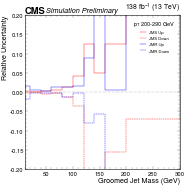

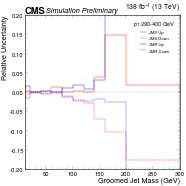

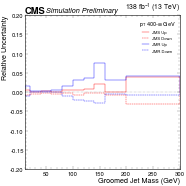

In [95]:
sys = 'JMS'
sys2 = 'JMR'
#sys3 = 'eletrig'
for ipt in range(npt):
    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][1], label = sys+' Up' , color = 'r' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][1], label = sys+' Down'  , ls = '--', color = 'r')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][1], label = sys2+' Up' , color ='b' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][1], label = sys2+' Down'  , ls = '--', color ='b')

    #hep.histplot(unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0],unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Up' , color = 'g')
    #hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Down'  , ls = '--', color = 'g')
    
    plt.hlines(0, 0, 300, color = 'k' , ls = '-.', alpha = 0.3)
    plt.legend(title = title_list[ipt], fontsize = 15, title_fontsize = 20)
    #plt.ylim(-0.1,0.1)
    if groomed:
        plt.xlabel("Groomed Jet Mass (GeV)")
        plt.xlim(10,300)
    else:
        plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.xlim(20,300)
    plt.ylabel("Relative Uncertainty")
    #plt.yscale('symlog')
    plt.ylim(-0.2, 0.2)
    #plt.yscale('symlog')
    hep.cms.label('Preliminary', rlabel = r"138 $fb^{-1}$ (13 TeV)")
    if groomed:
        plt.savefig(f'plots/uncertainties/{sys}_groomed_{ipt}.pdf', dpi = 300)
    else:
        plt.savefig(f'plots/uncertainties/{sys}_ungroomed_{ipt}.pdf', dpi = 300)
        
    
    plt.show()

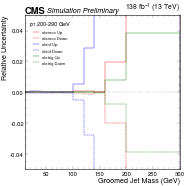

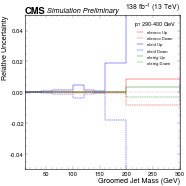

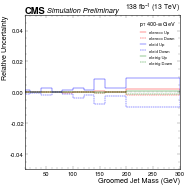

In [96]:
sys = 'elereco'
sys2 = 'eleid'
sys3 = 'eletrig'
for ipt in range(npt):
    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][1], label = sys+' Up' , color = 'r' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][1], label = sys+' Down'  , ls = '--', color = 'r')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][1], label = sys2+' Up' , color ='b' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][1], label = sys2+' Down'  , ls = '--', color ='b')

    hep.histplot(unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0],unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Up' , color = 'g')
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Down'  , ls = '--', color = 'g')
    
    plt.hlines(0, 0, 300, color = 'k' , ls = '-.', alpha = 0.3)
    plt.legend(title = title_list[ipt], fontsize = 15, title_fontsize = 20)
    #plt.ylim(-0.1,0.1)
    if groomed:
        plt.xlabel("Groomed Jet Mass (GeV)")
        plt.xlim(10,300)
    else:
        plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.xlim(20,300)
    plt.ylabel("Relative Uncertainty")
    #plt.yscale('symlog')
    plt.ylim(-0.05, 0.05)
    #plt.yscale('symlog')
    hep.cms.label('Preliminary', rlabel = r"138 $fb^{-1}$ (13 TeV)")
    if groomed:
        plt.savefig(f'plots/uncertainties/{sys}_groomed_{ipt}.pdf', dpi = 300)
    else:
        plt.savefig(f'plots/uncertainties/{sys}_ungroomed_{ipt}.pdf', dpi = 300)
        
    
    plt.show()

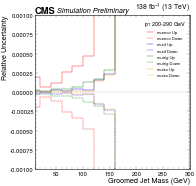

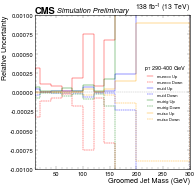

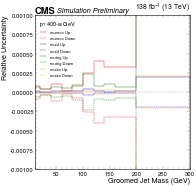

In [97]:
sys = 'mureco'
sys2 = 'muid'
sys3 = 'mutrig'
sys4 = 'muiso'
for ipt in range(npt):
    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][1], label = sys+' Up' , color = 'r' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][1], label = sys+' Down'  , ls = '--', color = 'r')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][1], label = sys2+' Up' , color ='b' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][1], label = sys2+' Down'  , ls = '--', color ='b')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys3+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys3+'Up'])[ipt][1], label = sys3+' Up' , color = 'g')
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Down'  , ls = '--', color = 'g')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys4+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys4+'Up'])[ipt][1], label = sys4+' Up' , color = 'orange')
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys4+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys4+'Down'])[ipt][1], label = sys4+' Down'  , ls = '--', color = 'orange')
    
    plt.hlines(0, 0, 300, color = 'k' , ls = '--', alpha = 0.3)
    plt.legend(title = title_list[ipt], fontsize = 15, title_fontsize = 20)
    #plt.ylim(-0.1,0.1)
    if groomed:
        plt.xlabel("Groomed Jet Mass (GeV)")
        plt.xlim(10,300)
    else:
        plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.xlim(20,300)
    plt.ylabel("Relative Uncertainty")
    #plt.yscale('symlog')
    plt.ylim(-0.001, 0.001)
    #plt.yscale('symlog')
    hep.cms.label('Preliminary', rlabel = r"138 $fb^{-1}$ (13 TeV)")
    if groomed:
        plt.savefig(f'plots/uncertainties/{sys}_groomed_{ipt}.pdf', dpi = 300)
    else:
        plt.savefig(f'plots/uncertainties/{sys}_ungroomed_{ipt}.pdf', dpi = 300)
        
    
    plt.show()

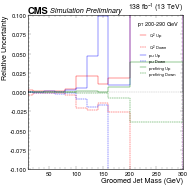

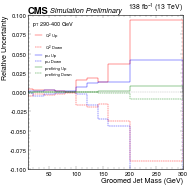

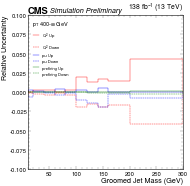

In [98]:
sys = 'q2'
sys2 = 'pu'
sys3 = 'prefiring'
for ipt in range(npt):
    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys+'Up'])[ipt][1], label =r'$Q^2$' +' Up' , color = 'r' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys+'Down'])[ipt][1], label = r'$Q^2$'+' Down'  , ls = '--', color = 'r')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys2+'Up'])[ipt][1], label = sys2+' Up' , color ='b' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys2+'Down'])[ipt][1], label = sys2+' Down'  , ls = '--', color ='b')

    hep.histplot(unfolder.plot_systematic_frac(sys_list = [sys3+'Up'])[ipt][0],unfolder.plot_systematic_frac(sys_list = [sys3+'Up'])[ipt][1], label = sys3+' Up' , color ='g' )
    hep.histplot(-unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][0], unfolder_dn.plot_systematic_frac(sys_list = [sys3+'Down'])[ipt][1], label = sys3+' Down'  , ls = '--', color ='g')
    
    plt.hlines(0, 0, 300, color = 'k' , ls = '--', alpha = 0.3)
    plt.legend(title = title_list[ipt], fontsize = 15, title_fontsize = 20)
    #plt.ylim(-0.1,0.1)
    if groomed:
        plt.xlabel("Groomed Jet Mass (GeV)")
        plt.xlim(10,300)
    else:
        plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.xlim(20,300)
    plt.ylabel("Relative Uncertainty")
    plt.ylim(-0.1, 0.1)
    #plt.yscale('symlog')
    hep.cms.label('Preliminary', rlabel = r"138 $fb^{-1}$ (13 TeV)")
    if groomed:
        plt.savefig(f'plots/uncertainties/{sys}_groomed_{ipt}.pdf', dpi = 300)
    else:
        plt.savefig(f'plots/uncertainties/{sys}_ungroomed_{ipt}.pdf', dpi = 300)
        
    
    plt.show()



In [99]:
unfolder_dn.plot_systematic_frac('total')

KeyError: 't'

In [170]:
for ipt in range(npt):
    for i in range(10):
        hep.histplot(jk_output_list[i][ipt]/mgen_width, mgen_edge)
        plt.xlim(20,200)
        if groomed:
            plt.xlabel("Groomed Jet Mass (GeV)")
        else:
            plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.ylabel("Arbitrary Normalization (1/GeV)")
    hep.cms.label()
    plt.savefig(f"plots/uncertainties/jackknife_{ipt}.png", dpi = 300)
    plt.show()
    

    

ValueError: operands could not be broadcast together with shapes (11,) (10,) 

/tmp/ipykernel_10318/770532368.py:3: RuntimeWarning: invalid value encountered in divide
  plt.stairs(unfolder.total_sys_jes[i*unfolder.nmbinsGen  :(i+1)*unfolder.nmbinsGen]/np.abs(unfolder.output_pt_binned[i]), unfolder.mgen_edge , label = "JESUp" , color = 'red', lw = 2)
/tmp/ipykernel_10318/770532368.py:4: RuntimeWarning: invalid value encountered in divide
  plt.stairs(-unfolder_dn.total_sys_jes[i*unfolder.nmbinsGen  :(i+1)*unfolder.nmbinsGen]/np.abs(unfolder.output_pt_binned[i]), unfolder.mgen_edge , label = "JESDown", ls = '--' , color = 'blue', lw = 2)


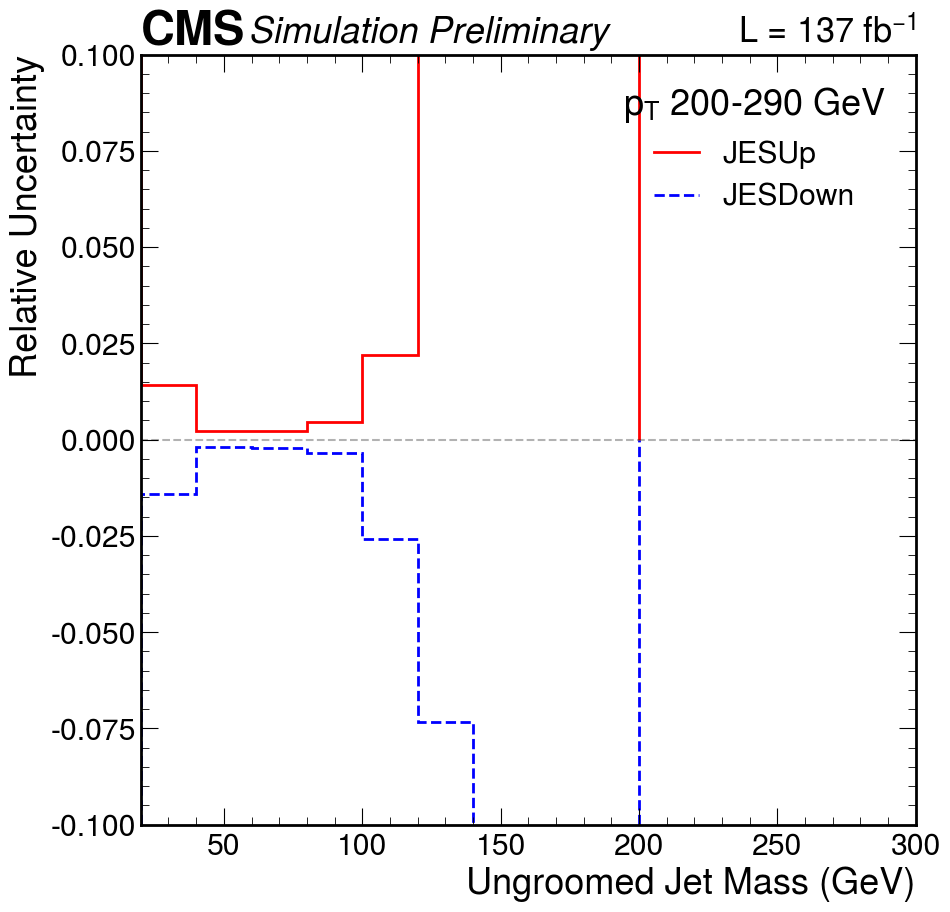

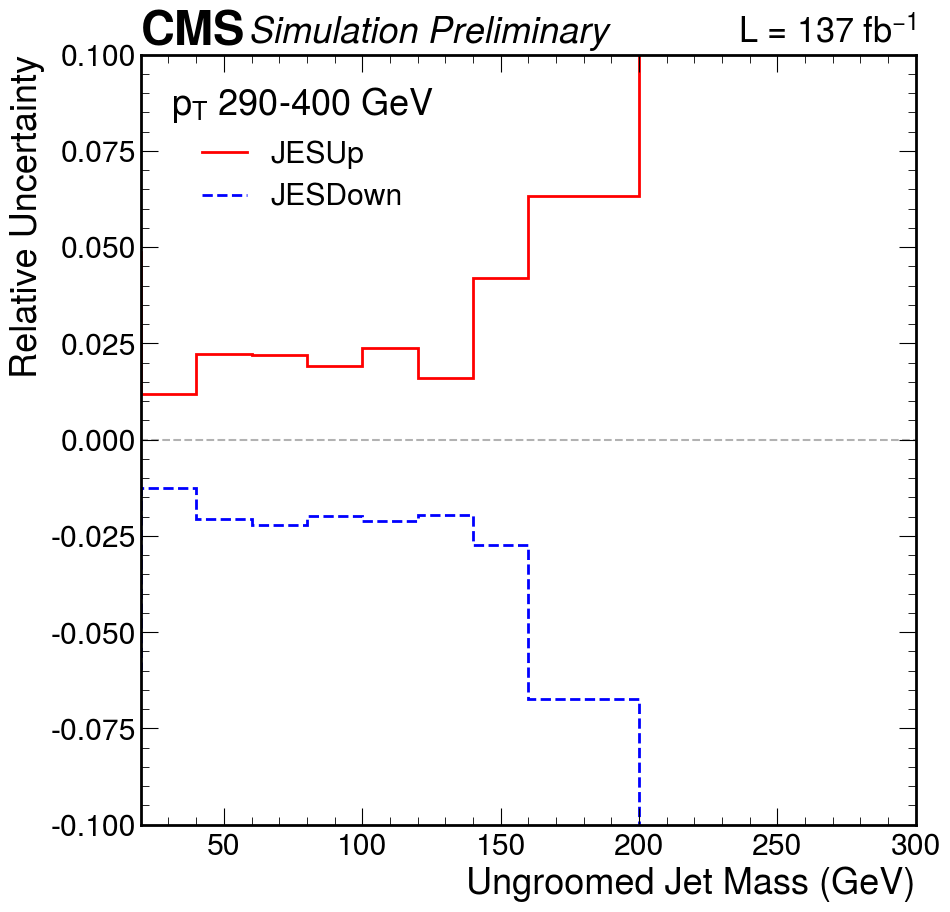

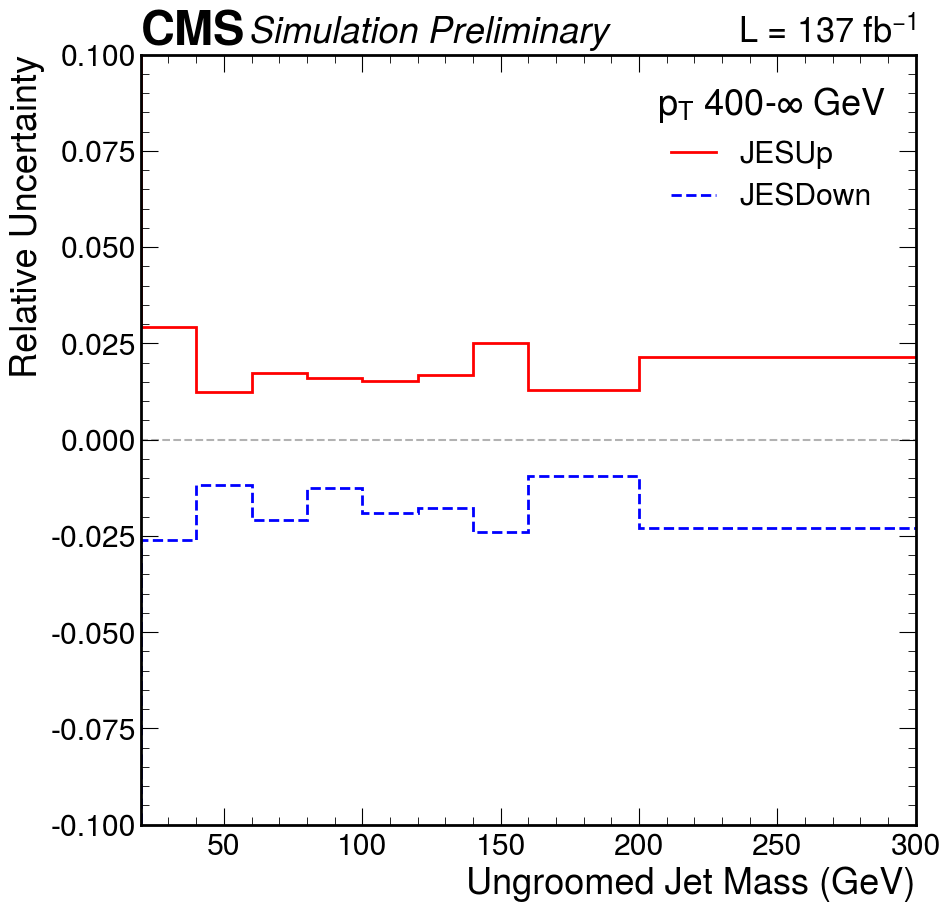

In [ ]:
#title_list = [ r"$p_T$ 200-290 GeV",  r"$p_T$ 290-400 GeV",  r"$p_T$ 400-480 GeV",  r"$p_T$ 480-$\infty$ GeV"]
for i in range(npt):
    plt.stairs(unfolder.total_sys_jes[i*unfolder.nmbinsGen  :(i+1)*unfolder.nmbinsGen]/np.abs(unfolder.output_pt_binned[i]), unfolder.mgen_edge , label = "JESUp" , color = 'red', lw = 2)
    plt.stairs(-unfolder_dn.total_sys_jes[i*unfolder.nmbinsGen  :(i+1)*unfolder.nmbinsGen]/np.abs(unfolder.output_pt_binned[i]), unfolder.mgen_edge , label = "JESDown", ls = '--' , color = 'blue', lw = 2)
    plt.hlines(0, 0, 300, color = 'k' , ls = '--', alpha = 0.3)
    plt.legend(title = title_list[i])
    #plt.ylim(-0.1,0.1)
    if groomed:
        plt.xlabel("Groomed Jet Mass (GeV)")
        plt.xlim(10,300)
    else:
        plt.xlabel("Ungroomed Jet Mass (GeV)")
        plt.xlim(20,300)
    plt.ylabel("Relative Uncertainty")
    plt.ylim(-0.1, 0.1)
    #plt.yscale('symlog')
    hep.cms.label('Preliminary', rlabel = r"138 $fb^{-1}$ (13 TeV)")
    if groomed:
        plt.savefig(f'plots/uncertainties/jes_groomed_{i}.png', dpi = 300)
    else:
        plt.savefig(f'plots/uncertainties/jes_ungroomed_{i}.png', dpi = 300)
        
    
    plt.show()

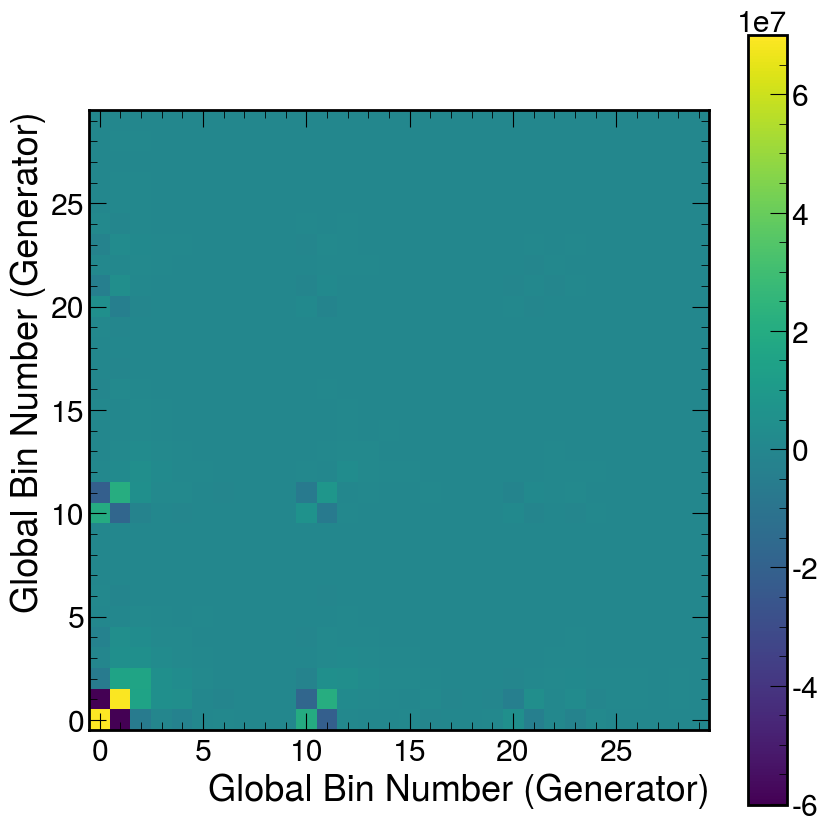

In [173]:
unfolder.plot_covariance()

In [174]:
input_data

Hist(
  StrCategory(['SingleElectron_UL2016', 'SingleMuon_UL2016', 'SingleElectron_UL2016APV', 'SingleMuon_UL2016APV', 'SingleElectron_UL2017', 'SingleMuon_UL2017', 'EGamma_UL2018', 'SingleMuon_UL2018'], growth=True, name='dataset', label='Primary dataset'),
  Variable([200, 290, 400, 13000], name='ptreco'),
  Variable([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 180, 200, 500, 13000], name='mreco'),
  StrCategory(['nominal'], growth=True, name='systematic', label='Systematic Uncertainty'),
  storage=Weight()) # Sum: WeightedSum(value=326263, variance=326263) (WeightedSum(value=330763, variance=330763) with flow)

In [175]:
input_data.project("ptreco", "mreco")[i,hist.rebin(1)].values().shape

(20,)

In [176]:
resp_matrix_4d.project("ptgen", "mgen").values().shape

(3, 10)

In [177]:
resp_matrix_4d.project("ptreco", "mreco")[:, hist.rebin(2)].values().shape

(3, 10)

/tmp/ipykernel_10318/700721889.py:11: RuntimeWarning: invalid value encountered in divide
  plt.plot(data_preunfold/mc_reco[i], marker = 'x')
/tmp/ipykernel_10318/700721889.py:12: RuntimeWarning: invalid value encountered in divide
  plt.plot(data_postunfold/mc[i], marker = 'o')


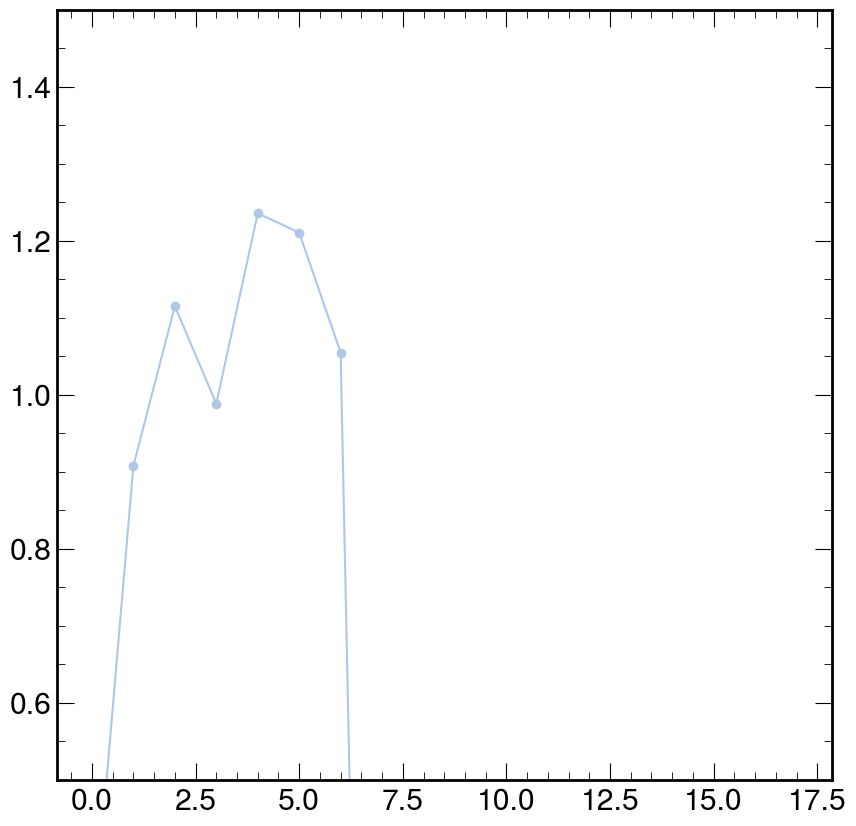

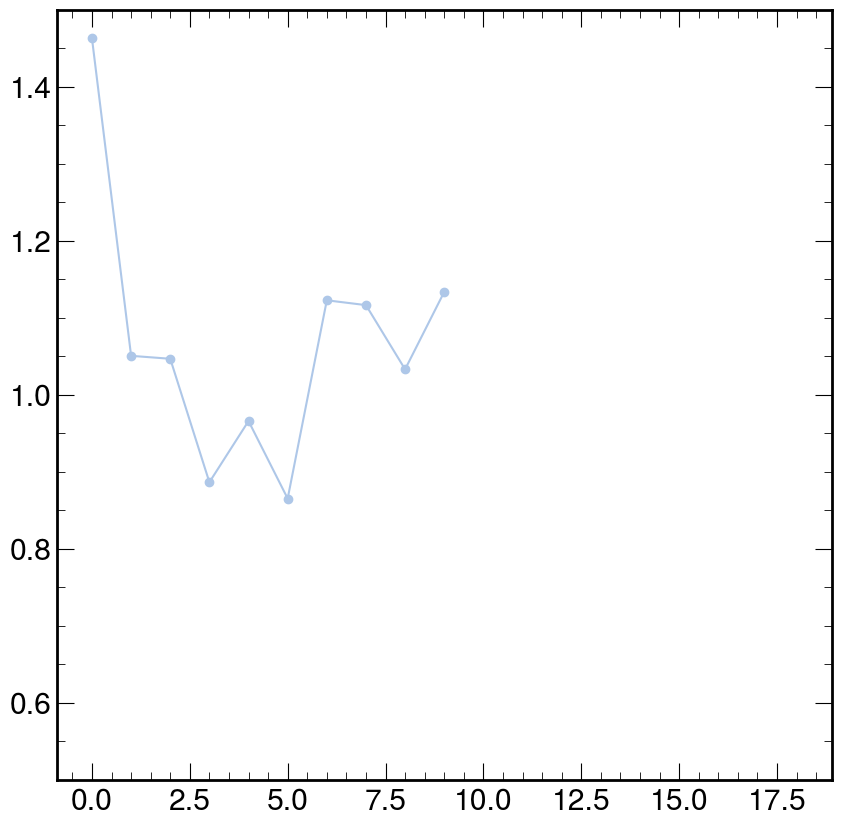

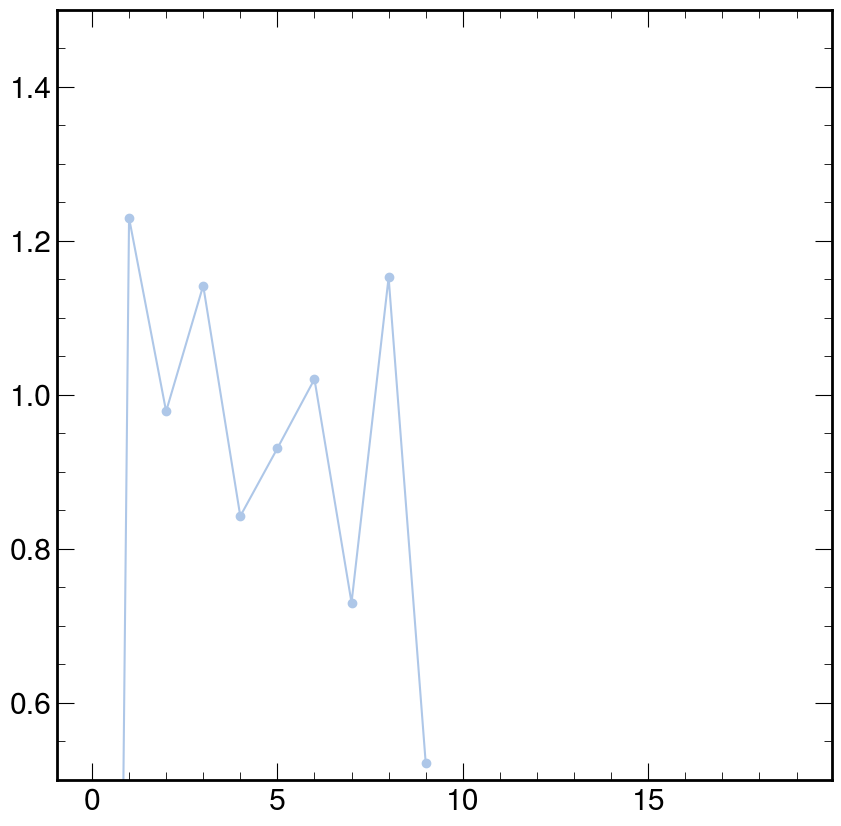

IndexError: index 3 is out of bounds for axis 0 with size 3

In [178]:
mc = resp_matrix_4d.project("ptgen", "mgen").values()
mc_reco =  resp_matrix_4d.project("ptreco", "mreco")[:, hist.rebin(1)].values()
mc_errors = resp_matrix_4d.project("ptgen", "mgen").variances()**0.5

for i in range(4):

    mc[i] = mc[i]/mc[i][:-1].sum()
    data_postunfold = unfolder.get_results()[0][i]/unfolder.get_results()[0][i][:-1].sum()
    data_preunfold = input_data.project("ptreco", "mreco")[i,hist.rebin(1)].values()/input_data.project("ptreco", "mreco")[i,hist.rebin(1)].values()[:-1].sum()
    
    plt.plot(data_preunfold/mc_reco[i], marker = 'x')
    plt.plot(data_postunfold/mc[i], marker = 'o')
    plt.ylim(0.5,1.5)
    plt.show()


    

In [179]:
np.sqrt(input_data.project("ptreco", "mreco")[i, hist.rebin(2)].values())

IndexError: histogram index is out of range

In [180]:
input_data.project("ptreco", "mreco")[i, hist.rebin(2)].values()

IndexError: histogram index is out of range

In [181]:
input_data.project("ptreco", "mreco")[i, hist.rebin(2)].values()

IndexError: histogram index is out of range

In [182]:
data_preunfold

array([3.81184722e-05, 3.62125486e-03, 3.24769383e-02, 1.00709004e-01,
       1.38941831e-01, 1.43363574e-01, 1.21750400e-01, 9.42288633e-02,
       7.15864908e-02, 5.92361058e-02, 4.58565221e-02, 3.76229321e-02,
       3.08378440e-02, 2.42814668e-02, 2.00503164e-02, 1.55523367e-02,
       2.55393764e-02, 1.56285736e-02, 1.86780514e-02, 7.62369444e-05])

In [183]:
stat_unc[0]

array([ 121.47725789,   82.98288583,   76.86705607,  133.72464047,
        188.96737397,  288.60134954,  484.93278893,  194.87958711,
         92.47993425,   39.72560703, 1432.51440451])

In [184]:
unfolder.stat_pt_binned[0]

array([ 733.1896953 , 1428.45691237, 1211.19059448,  704.13188528,
        509.91264713,  358.93714269,  224.05402262,  100.74965923,
         12.1356135 ,    0.        ])

In [185]:
for i in range(4):
    # Normalize the distributions
    fig = plt.figure(figsize = (10,4))
    mc[i] = mc[i] / mc[i].sum()
    mc_reco[i] = mc_reco[i]/mc_reco[i].sum()
    data_postunfold = unfolder.get_results()[0][i] / unfolder.get_results()[0][i].sum()
    data_preunfold = input_data.project("ptreco", "mreco")[i, hist.rebin(1)].values() / input_data.project("ptreco", "mreco")[i, hist.rebin(1)].values().sum()

    # Calc`ulate uncertainties (example: Poisson sqrt)
    mc_unc = np.sqrt(mc[i]) / mc[i].sum()
    #post_unc = np.sqrt( unfolder.get_results()[0][i]) / unfolder.get_results()[0][i].sum()/mc[i]
    post_unc = stat_unc[i] / unfolder.get_results()[0][i].sum()/mc[i]
    pre_unc = np.sqrt( input_data.project("ptreco", "mreco")[i, hist.rebin(1)].values()) /  input_data.project("ptreco", "mreco")[i, hist.rebin(1)].values().sum()/mc_reco[i]

    # Plot using stairs with uncertainty bars
    plt.stairs(data_preunfold/mc_reco[i], edges=mreco_edge, label='Pre-unfold / MC', color='blue', ls = '--')
    plt.errorbar((mreco_edge[:-1] + mreco_edge[1:]) / 2, data_preunfold/mc_reco[i], yerr=pre_unc,  fmt='x', color='blue')

    plt.stairs(data_postunfold/mc[i], edges=mgen_edge_mod, label='Post-unfold / MC', color='green')
    plt.errorbar((mgen_edge_mod[:-1] + mgen_edge_mod[1:]) / 2, data_postunfold/mc[i], yerr=post_unc, fmt='o', color='green')
    plt.hlines([1], 0, 240 , color = 'k')
    plt.ylim(0.5, 1.5)
    plt.xlim(0,240)
    if groomed:
        plt.xlabel('Groomed Jet Mass (GeV)')
        plt.savefig(f"plots/unfold/bottom_line_groomed_{i}.pdf")
    else:
        plt.xlabel('Ungroomed Jet Mass (GeV)')
        plt.savefig(f"plots/unfold/bottom_line_ungroomed_{i}.pdf")
    plt.ylabel('Ratio')
    plt.legend()
    plt.show()


ValueError: operands could not be broadcast together with shapes (11,) (10,) 

<Figure size 1000x400 with 0 Axes>

In [187]:
herwig_input = resp_matrix_4d_herwig.project('ptreco', 'mreco')

In [164]:
jk_output_list = []
for i in range(10):
    if not groomed:
        resp_matrix_4d_jk = output_jk['jk_response_matrix_u'][{'jk':i}]
        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'mreco',edges )
        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'mgen',edges_gen )

        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'ptreco',pt_edges )
        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'ptgen', pt_edges )
        
        input_data = output_data['ptjet_mjet_u_reco']
        input_data = rebin_hist(input_data, 'mreco',edges)
        input_data = rebin_hist(input_data, 'ptreco',pt_edges)
        fakes_jk = fakes
        misses_jk = (9/10)*misses
        

    else:
        resp_matrix_4d_jk = output_jk['jk_response_matrix_g'][{'jk':i}]
        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'mreco',edges )
        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'mgen',edges_gen )

        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'ptreco',pt_edges )
        resp_matrix_4d_jk= rebin_hist(resp_matrix_4d_jk, 'ptgen', pt_edges )
        
        input_data = output_data['ptjet_mjet_g_reco']
        input_data = rebin_hist(input_data, 'mreco',edges)
        input_data = rebin_hist(input_data, 'ptreco',pt_edges)
        fakes_jk = fakes
        misses_jk = (9/10)*misses

    unfolder_jk = Unfolder(input_data, resp_matrix_4d_jk[{'systematic':'nominal'}] , fakes_jk, misses_jk,
                            backgrounds = {"ww": ww_bg, "wz":wz_bg, "zz": zz_bg},
                            #systematics = {'JES_AbsoluteMPFBiasUp': resp_matrix_4d[{'systematic':'JES_AbsoluteMPFBiasUp'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()  },
                            #systematics = sys_matrix_dic_down,
                            systematics= None,
                            closure = closure,
                            groomed = groomed,
                            is_uf = True,
                            merge = False,
                            normalised_xs = True,
                            do_syst = True,
                            discard_low_bins = False,
                            regularisation= 'ScanSURE',
                            do_norm = False
                                   )

    unfolder_jk.perform_unfold()
    jk_output_list.append(unfolder_jk.get_results()[0][:3])
        
    # resp_matrix_4d_jk = resp_matrix_4d_jk[:,:,:hist.loc(131), : ,:hist.loc(121),:] 
    # resp_matrix_4d_jk[:,:,hist.loc(121), : ,:,:] = resp_matrix_4d_jk[:,:,hist.loc(121), : ,:,:].view() + resp_matrix_4d_jk[:,:,hist.loc(131), : ,:,:].view()
    # resp_matrix_4d_jk[:,:,:, : ,hist.loc(111),:] = resp_matrix_4d_jk[:,:,:, : ,hist.loc(111),:].view() + resp_matrix_4d_jk[:,:, :, : ,hist.loc(121),:].view()



10
[    0.    20.    40.    60.    80.   100.   120.   140.   160.   200.
 13000.]
20
[0.0e+00 1.0e+01 2.0e+01 3.0e+01 4.0e+01 5.0e+01 6.0e+01 7.0e+01 8.0e+01
 9.0e+01 1.0e+02 1.1e+02 1.2e+02 1.3e+02 1.4e+02 1.5e+02 1.6e+02 1.8e+02
 2.0e+02 5.0e+02 1.3e+04]
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
3.22558071
3.22558071
3.22558071
3.22558071
3.22558071
3.22558071
3.22558071
3.22558071
3.22558071
3.22558071
7.93939854
7.93939854
7.93939854
7.93939854
7.93939854
7.93939854
7.93939854
7.93939854
7.93939854
Detector Binning created
shape of you (60,)
Working until background subtractions
Unfolder object created
Regularisation USED ScanSURE
Tau value 8.462029990036912e-06
10
[    0.    20.    40.    60.    80.   100.   120.   140.   160.   200.
 13000.]
20
[0.0e+00 1.0e+01 2.0e+01 3.0e+01 4.0e+01 5.0e+01 6.0e+01 7.0e+01 8.0e+01
 9.0e+01 1.0e+02 1.1e+02 1.2e+02 1.3e+02 1.4e+02 1.5e+02 1.6e+02 1.8e+02
 2.0e+02 5.0e+02 1.3e+04]
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
3.22558071
3.22558071
3.2255

/home/aritra/workspace/unfold/unfold_utils/unfolderv3.py:125: RuntimeWarning: invalid value encountered in divide
  self.underflow_frac = np.nan_to_num(h_np_underflow / self.M_np.sum(axis=0))
/home/aritra/workspace/unfold/unfold_utils/unfolderv3.py:176: RuntimeWarning: invalid value encountered in divide
  self.miss_frac = self.miss_values/ ( self.M_np.sum(axis = 1))


Regularisation USED ScanSURE
Tau value 8.223675098698256e-06
10
[    0.    20.    40.    60.    80.   100.   120.   140.   160.   200.
 13000.]
20
[0.0e+00 1.0e+01 2.0e+01 3.0e+01 4.0e+01 5.0e+01 6.0e+01 7.0e+01 8.0e+01
 9.0e+01 1.0e+02 1.1e+02 1.2e+02 1.3e+02 1.4e+02 1.5e+02 1.6e+02 1.8e+02
 2.0e+02 5.0e+02 1.3e+04]
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
3.22558071
3.22558071
3.22558071
3.22558071
3.22558071
3.22558071
3.22558071
3.22558071
3.22558071
3.22558071
7.93939854
7.93939854
7.93939854
7.93939854
7.93939854
7.93939854
7.93939854
7.93939854
7.93939854
Detector Binning created
shape of you (60,)
Working until background subtractions
Unfolder object created
Regularisation USED ScanSURE
Tau value 8.610092211762412e-06
10
[    0.    20.    40.    60.    80.   100.   120.   140.   160.   200.
 13000.]
20
[0.0e+00 1.0e+01 2.0e+01 3.0e+01 4.0e+01 5.0e+01 6.0e+01 7.0e+01 8.0e+01
 9.0e+01 1.0e+02 1.1e+02 1.2e+02 1.3e+02 1.4e+02 1.5e+02 1.6e+02 1.8e+02
 2.0e+02 5.0e+02 1.3e+04]
1.0
1.0

Warning in <TROOT::Append>: Replacing existing TH1: M (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_reco (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htrue (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htruef (Potential memory leak).
Info in <TUnfold::SetConstraint>: fConstraint=1
Warning in <TUnfold::TUnfold>: 3 output bins do not depend on the input data  0 10 31
Info in <TUnfold::TUnfold>: 60 input bins and 29 output bins
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #0
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #10 (signal:ptgen[200,290]:massgen[200,1.3e+04])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #31
Info in <TUnfoldDensity::RegularizeOneDistribution>: regularizing signal regMode=3 densityMode=3 axisSteering=*[UOB]
Warning in <TUnfoldDensity::SetInput>: 5/60 input bins hav

In [165]:
jk_output_list[0]

[array([ 1.18515228e-01, -5.18994208e-01,  6.07536437e-01,  5.13935272e-01,
         2.08214978e-01,  6.52926058e-02,  5.69122359e-03, -1.55649827e-04,
        -3.58872099e-05,  0.00000000e+00]),
 array([ 2.28268540e-04,  3.84129165e-01,  3.35607938e-01,  1.26249660e-01,
         7.87128043e-02,  3.93057471e-02,  2.38344816e-02,  9.67011723e-03,
         2.32781733e-03, -6.59993400e-05]),
 array([-0.01586579, -0.30357382,  0.28775584,  0.38883047,  0.20495423,
         0.14932506,  0.1158778 ,  0.05554408,  0.09333212,  0.02382003])]

In [166]:
jk_output_list = np.array(jk_output_list)

stat_unc = np.sqrt(10/9)*np.std(jk_output_list, axis = 0)

stat_unc.shape

(3, 10)

/tmp/ipykernel_726/3025371949.py:1: RuntimeWarning: invalid value encountered in divide
  plt.stairs(stat_unc.reshape(30)/jk_output_list[0].reshape(30))


(0.0, 0.2)

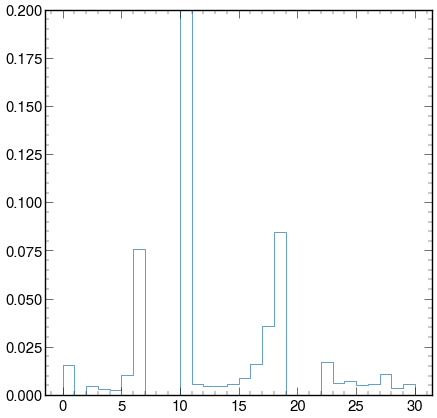

In [170]:
plt.stairs(stat_unc.reshape(30)/jk_output_list[0].reshape(30))
plt.ylim(0,0.2)

In [191]:
if groomed:
    np.savetxt('stat_mat_groomed.txt', stat_unc)
else:
    np.savetxt( 'stat_mat_ungroomed.txt', stat_unc,)

In [192]:
resp_matrix_4d_herwig[{'systematic':'herwig'}].values().shape

(4, 3, 20, 3, 10)

In [193]:
input_data.values().shape

(8, 3, 20, 1)

In [77]:
unfolder_herwig = Unfolder(input_data, resp_matrix_4d_herwig[{'systematic':'herwig'}] , fakes = None, misses = None,
                            backgrounds = None,
                            #systematics = {'JES_AbsoluteMPFBiasUp': resp_matrix_4d[{'systematic':'JES_AbsoluteMPFBiasUp'}].project('ptgen', 'mgen', 'ptreco', 'mreco').values()  },
                            #systematics = sys_matrix_dic,
                            systematics= None,
                            closure = False,
                            groomed = groomed,
                            is_uf = True,
                            merge = False,
                            normalised_xs = True,
                            do_syst = False,
                            discard_low_bins = False,
                            regularisation= 'ScanSURE',
                            do_norm = False
                                   )

10
[    0.    20.    40.    60.    80.   100.   120.   140.   160.   200.
 13000.]
20
[0.0e+00 1.0e+01 2.0e+01 3.0e+01 4.0e+01 5.0e+01 6.0e+01 7.0e+01 8.0e+01
 9.0e+01 1.0e+02 1.1e+02 1.2e+02 1.3e+02 1.4e+02 1.5e+02 1.6e+02 1.8e+02
 2.0e+02 5.0e+02 1.3e+04]
6.672843e-06
6.672843e-06
6.672843e-06
6.672843e-06
6.672843e-06
6.672843e-06
6.672843e-06
6.672843e-06
6.672843e-06
6.672843e-06
2.15237936e-05
2.15237936e-05
2.15237936e-05
2.15237936e-05
2.15237936e-05
2.15237936e-05
2.15237936e-05
2.15237936e-05
2.15237936e-05
2.15237936e-05
5.297836e-05
5.297836e-05
5.297836e-05
5.297836e-05
5.297836e-05
5.297836e-05
5.297836e-05
5.297836e-05
5.297836e-05
Detector Binning created
shape of you (60,)


In [78]:
unfolder_herwig.perform_unfold()

Unfolder object created
Regularisation USED ScanSURE
Tau value 0.008058421877614819


Warning in <TROOT::Append>: Replacing existing TH1: M (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_reco (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htrue (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: htruef (Potential memory leak).
Info in <TUnfold::SetConstraint>: fConstraint=1
Warning in <TUnfold::TUnfold>: 4 output bins do not depend on the input data  0 9-10 31
Info in <TUnfold::TUnfold>: 60 input bins and 28 output bins
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #0
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #9 (signal:ptgen[200,290]:massgen[160,200])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #10 (signal:ptgen[200,290]:massgen[200,1.3e+04])
Info in <TUnfoldDensity::TUnfold>: *NOT* unfolding bin #31
Info in <TUnfoldDensity::RegularizeOneDistribution>: regularizing signal r

AttributeError: 'Unfolder' object has no attribute 'miss_values'

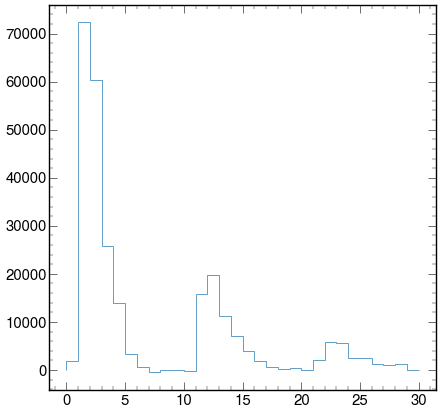

In [79]:
unfolder_herwig.plot_unfolded()

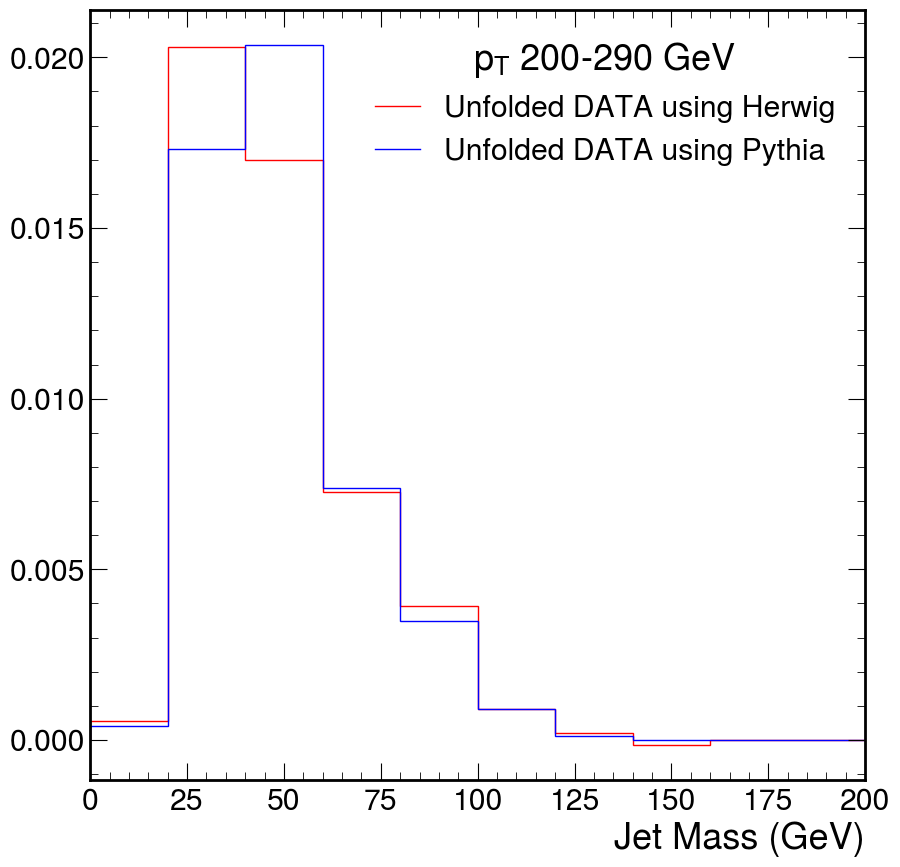

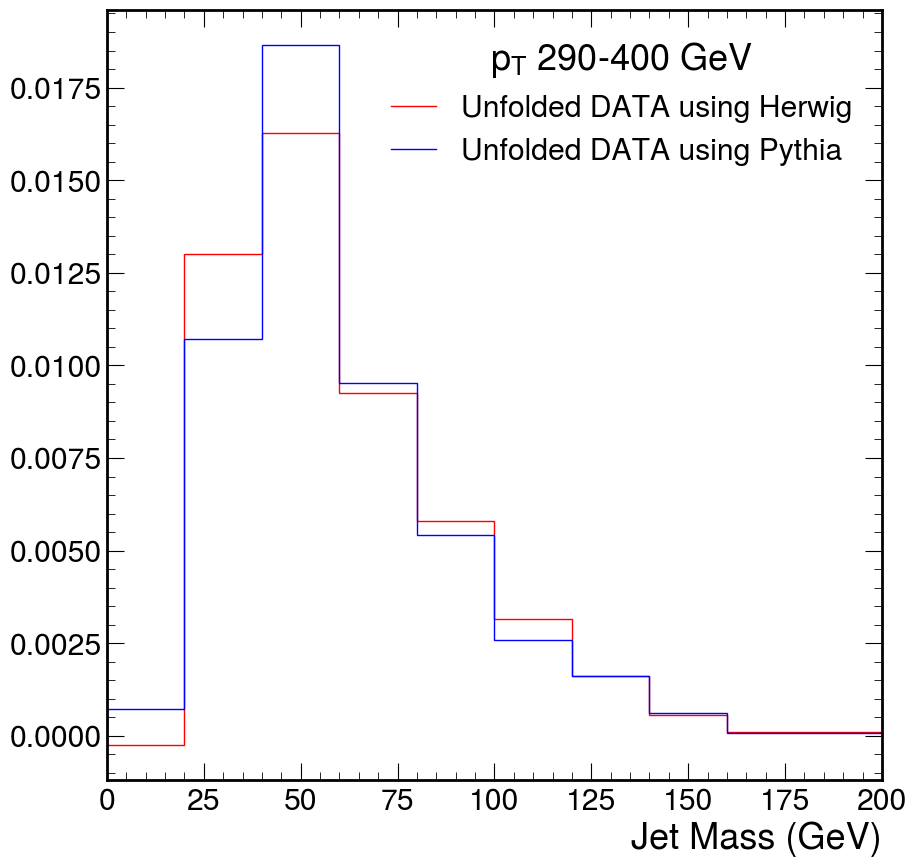

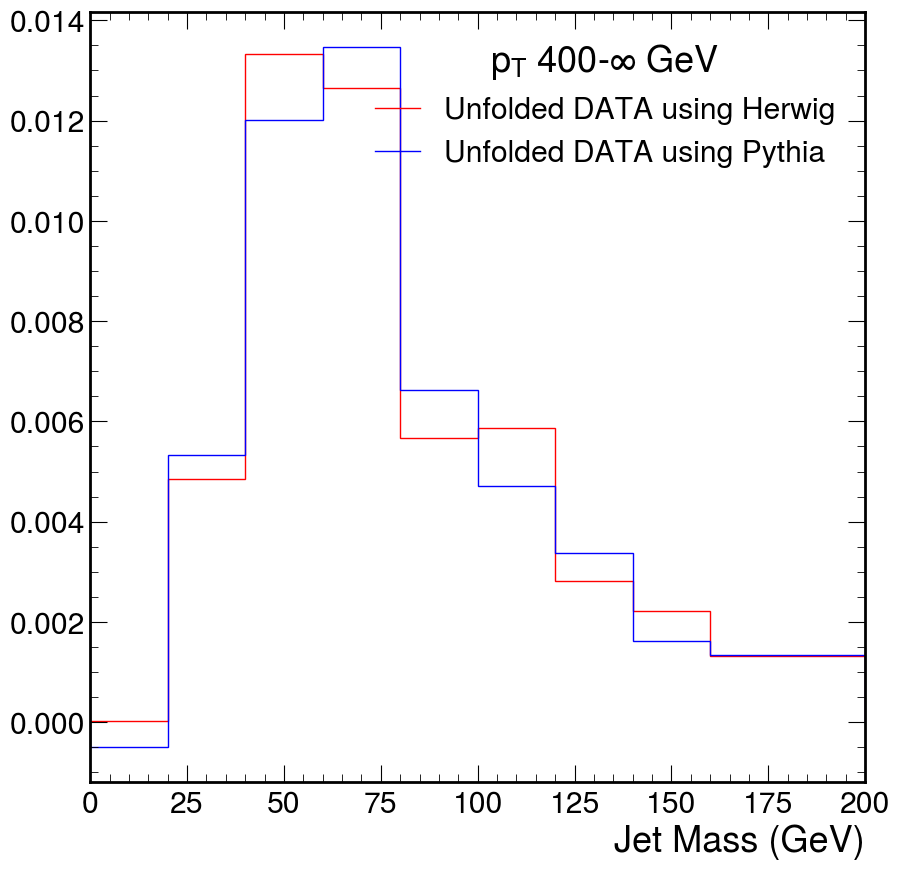

In [197]:
pythia_output = unfolder.get_results()[0]
herwig_output = unfolder_herwig.get_results()[0]
for ipt in range(3):
    # if groomed:
        
    #     herwig_normalised  = herwig_output[ipt]/herwig_output[ipt].sum()
    #     pythia_normalised = pythia_output[ipt]/pythia_output[ipt].sum()
    #     plt.stairs(herwig_normalised/mgen_width, mgen_edge, color = 'r', label = 'Unfolded DATA using Herwig')
    #     plt.stairs(pythia_normalised/mgen_width, mgen_edge, color = 'b', label = 'Unfolded DATA using Pythia')
    #     plt.legend(title = title_list[ipt])
    #     plt.xlim(0,200)
    #     plt.xlabel("Jet Mass (GeV)")
    #     plt.show()
        
    if (ipt!=3):
        herwig_normalised  = herwig_output[ipt]/herwig_output[ipt].sum()
        pythia_normalised = pythia_output[ipt]/pythia_output[ipt].sum()
        plt.stairs(herwig_normalised/mgen_width, mgen_edge, color = 'r', label = 'Unfolded DATA using Herwig')
        plt.stairs(pythia_normalised/mgen_width, mgen_edge, color = 'b', label = 'Unfolded DATA using Pythia')
        plt.legend(title = title_list[ipt])
        plt.xlim(0,200)
        plt.xlabel("Jet Mass (GeV)")
        plt.show()
    else:
        
        # Normalize Herwig and Pythia distributions
        herwig_normalised = herwig_output[ipt] / herwig_output[ipt].sum()
        pythia_normalised = pythia_output[ipt] / pythia_output[ipt].sum()
        
        # Define the indices to merge
        if not groomed:
            merge_indices = [(1, 2), (4, 5)]  # Python index is 0-based, so (2nd,3rd) -> (1,2) and (5th,6th) -> (4,5)
        else:
            merge_indices = [(3,4), (5,6)]
        # Merge the bin values
        def merge_bins(data, bin_edges, merge_indices):
            new_data = list(data)
            new_edges = list(bin_edges)
        
            for i, j in reversed(merge_indices):  # Reverse to avoid shifting indices
                new_data[i] += new_data[j]  # Sum the values
                del new_data[j]  # Remove the merged element
                new_edges[i + 1] = new_edges[j + 1]  # Extend the bin range
                del new_edges[j + 1]  # Remove the extra bin edge
        
            new_width = np.diff(new_edges)  # Recalculate bin widths
            return np.array(new_data), np.array(new_edges), new_width
        
        # Apply merging
        herwig_merged, mgen_edge_merged, mgen_width_merged = merge_bins(herwig_normalised, mgen_edge, merge_indices)
        pythia_merged, _, _ = merge_bins(pythia_normalised, mgen_edge, merge_indices)  # Use the same edges for Pythia
        
        # Plot the modified histograms
        plt.stairs(herwig_merged / mgen_width_merged, mgen_edge_merged, color='r', label='Unfolded DATA using Herwig')
        plt.stairs(pythia_merged / mgen_width_merged, mgen_edge_merged, color='b', label='Unfolded DATA using Pythia')
        
        plt.legend(title=title_list[ipt])
        plt.xlim(0, 200)
        plt.xlabel("Jet Mass (GeV)")
        plt.show()


    

/tmp/ipykernel_10318/1747942830.py:16: RuntimeWarning: invalid value encountered in divide
  diff = np.abs(pythia_normalised-herwig_normalised)/2/np.abs(pythia_normalised)


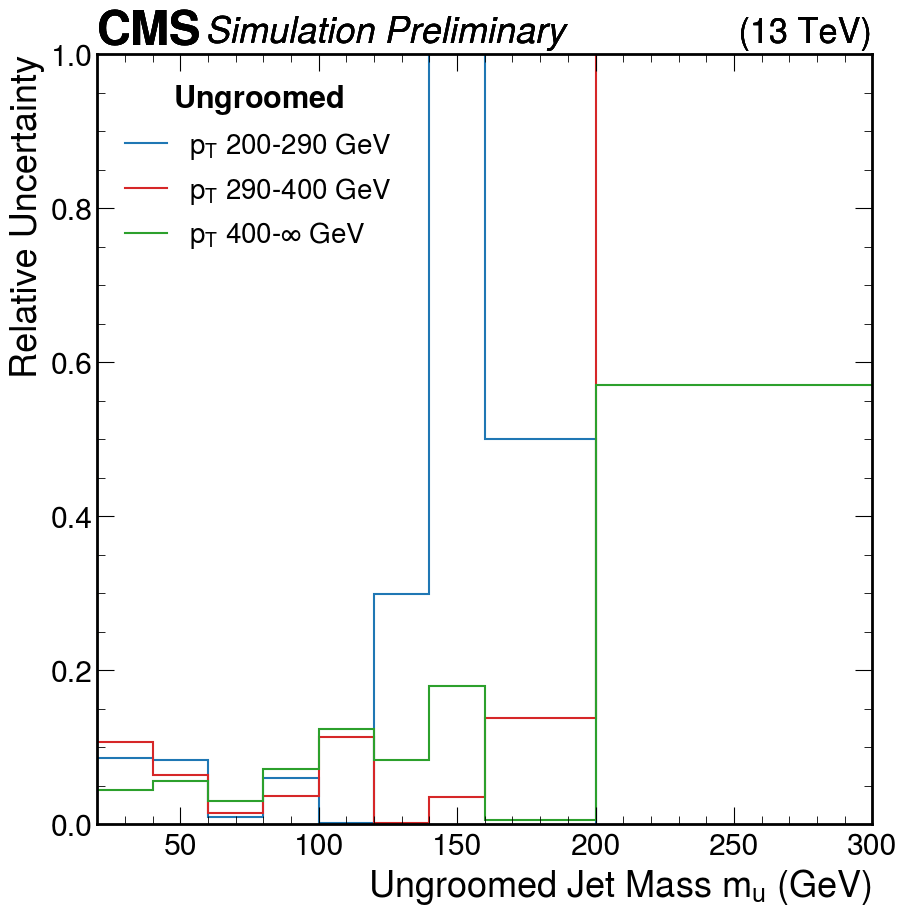

In [198]:
relative_herwig = []

for ipt in range(npt):
    # if groomed:

    #     herwig_normalised  = herwig_output[ipt]/herwig_output[ipt].sum()
    #     pythia_normalised = pythia_output[ipt]/pythia_output[ipt].sum()
    #     diff = np.abs(pythia_normalised-herwig_normalised)/2/np.abs(pythia_normalised)
    #     hep.histplot(diff, mgen_edge, label = title_list[ipt], color = color_pt[ipt])
    #     plt.xlim(10,300)
    #     plt.ylim(0,1)
    #     #plt.show()
    if ipt!=3:
        herwig_normalised  = herwig_output[ipt]/herwig_output[ipt].sum()
        pythia_normalised = pythia_output[ipt]/pythia_output[ipt].sum()
        diff = np.abs(pythia_normalised-herwig_normalised)/2/np.abs(pythia_normalised)
        hep.histplot(diff, mgen_edge, label = title_list[ipt], color = color_pt[ipt])
        plt.xlim(20,300)
        plt.ylim(0,1)
        #plt.show()
    else:
        
        diff = np.abs(pythia_merged-herwig_merged)/2/np.abs(pythia_merged)
        hep.histplot(diff, mgen_edge_merged, label = title_list[ipt], color = color_pt[ipt])
        plt.xlim(20,300)
        plt.ylim(0,1)
        #plt.show()

    relative_herwig.append(diff)
    
    
    plt.ylabel("Relative Uncertainty")
    hep.cms.label("Preliminary", data = False)
    if groomed:
        plt.legend(title=r"$\bf{Groomed}$", fontsize = 20, title_fontsize = 22)
        plt.xlabel(r"Groomed Jet Mass $m_u$ (GeV)")
        plt.savefig(f"plots/unfold/herwig_unc_groomed.pdf")
    else:
        plt.legend(title=r"$\bf{Ungroomed}$", fontsize = 20, title_fontsize = 22)
        plt.xlabel(r"Ungroomed Jet Mass $m_u$ (GeV)")
        plt.savefig(f"plots/unfold/herwig_unc_ungroomed.pdf")

In [199]:
total_sys_pt_bin = unfolder.total_sys_pt_binned

total_sys_pt_bin_down = unfolder_dn.total_sys_pt_binned

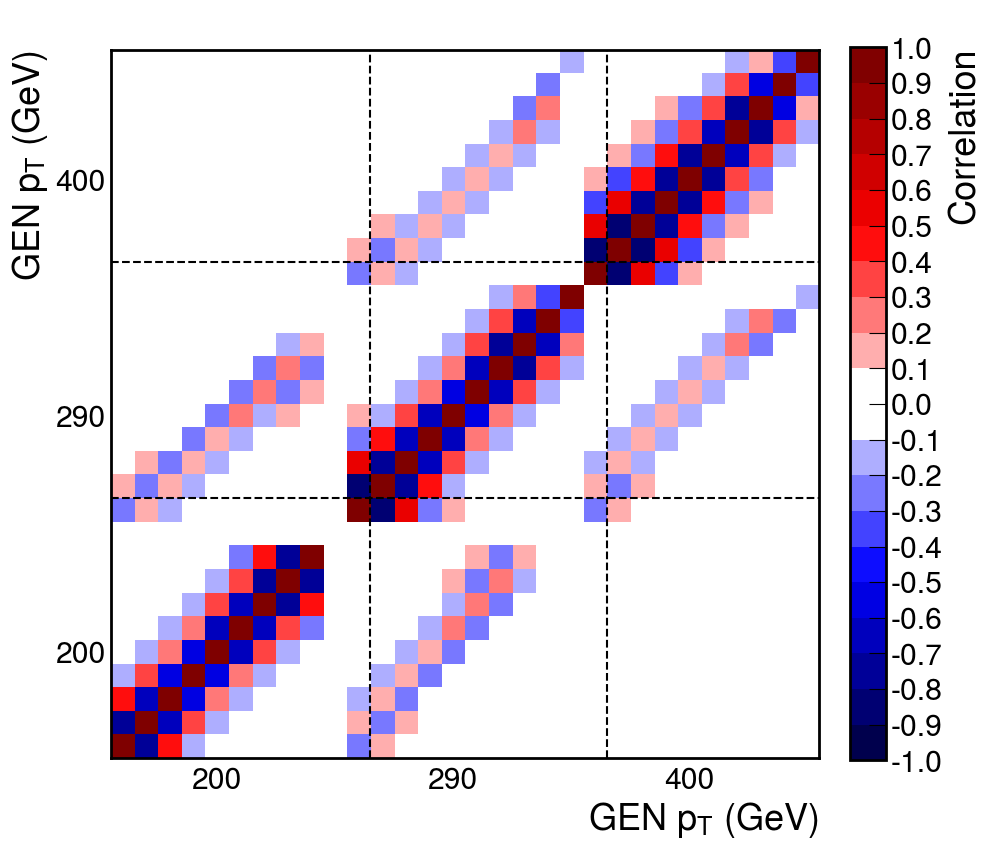

In [200]:
unfolder.plot_correlation()
corr_matrix = unfolder.corr_matrix

In [201]:
############## Up ##################

total_sys_w_herwig_pt_binned = []
total_sys_down_w_herwig_pt_binned = []
unfolded_result_dic = {}
for ipt in range(npt):
    if ipt !=3:
        nominal_result = unfolder.get_results()[0][ipt]
        herwig_unc = nominal_result*relative_herwig[ipt]

        ######### Up ###############
        total_sys2 = total_sys_pt_bin[ipt]**2       
        total_sys2 += herwig_unc
        total_sys = total_sys2**0.5
        total_sys_w_herwig_pt_binned.append(total_sys)
        ######### Down ###############
        total_sys2_down = total_sys_pt_bin_down[ipt]**2
        total_sys2_down += herwig_unc
        total_sys_down = total_sys2_down**0.5
        total_sys_down_w_herwig_pt_binned.append(total_sys_down)
        
        unfolded_result_dic[ipt] = nominal_result
    else:
        pythia_merged, _, _ = merge_bins(pythia_output[ipt], mgen_edge, merge_indices)
        nominal_result = pythia_merged
        
        herwig_unc = nominal_result*relative_herwig[ipt]
        if not groomed:
            corr_12 = corr_matrix[30+1, 30+2]
            corr_45 = corr_matrix[30+4, 30+5]

            ############# Up ##############
            total_sys_final_bin = total_sys_pt_bin[ipt]
            
            
            s1 = total_sys_final_bin[1]
            s2 = total_sys_final_bin[2]
            s4 =  total_sys_final_bin[4]
            s5 =  total_sys_final_bin[5]
    
            s1 = np.sqrt(s1**2 + s2**2 + 2*corr_12*s1*s2)
            s4 = np.sqrt(s4**2 + s5**2 + 2*corr_45*s4*s5)
    
            total_sys_final_bin[4] = s4
            total_sys_final_bin = np.delete(total_sys_final_bin, 5)
            total_sys_final_bin[1] = s1
            total_sys_final_bin = np.delete(total_sys_final_bin, 2)

            ############# Down ##############

            total_sys_final_bin_down = total_sys_pt_bin_down[ipt]
            
            
            s1 = total_sys_final_bin_down[1]
            s2 = total_sys_final_bin_down[2]
            s4 =  total_sys_final_bin_down[4]
            s5 =  total_sys_final_bin_down[5]
    
            s1 = np.sqrt(s1**2 + s2**2 + 2*corr_12*s1*s2)
            s4 = np.sqrt(s4**2 + s5**2 + 2*corr_45*s4*s5)
    
            total_sys_final_bin_down[4] = s4
            total_sys_final_bin_down = np.delete(total_sys_final_bin_down, 5)
            total_sys_final_bin_down[1] = s1
            total_sys_final_bin_down = np.delete(total_sys_final_bin_down, 2)
        else:

            
            corr_34 = corr_matrix[30+3, 30+4]
            corr_56 = corr_matrix[30+5, 30+6]


            ######### Up ####################
            total_sys_final_bin = total_sys_pt_bin[ipt]
            
            s3 = total_sys_final_bin[3]
            s4 = total_sys_final_bin[4]
            s5 = total_sys_final_bin[5]
            s6 = total_sys_final_bin[6]
            
            s3 = np.sqrt(s3**2 + s4**2 + 2*corr_34*s3*s4)
            s5 = np.sqrt(s5**2 + s6**2 + 2*corr_56*s5*s6)
            
            total_sys_final_bin[3] = s3
            total_sys_final_bin = np.delete(total_sys_final_bin, 4)
            total_sys_final_bin[5] = s5
            total_sys_final_bin = np.delete(total_sys_final_bin, 6)

            ############ Down ####################
            total_sys_final_bin_down = total_sys_pt_bin_down[ipt]
            
            s3 = total_sys_final_bin_down[3]
            s4 = total_sys_final_bin_down[4]
            s5 = total_sys_final_bin_down[5]
            s6 = total_sys_final_bin_down[6]
            
            s3 = np.sqrt(s3**2 + s4**2 + 2*corr_34*s3*s4)
            s5 = np.sqrt(s5**2 + s6**2 + 2*corr_56*s5*s6)
            
            total_sys_final_bin_down[3] = s3
            total_sys_final_bin_down = np.delete(total_sys_final_bin_down, 4)
            total_sys_final_bin_down[5] = s5
            total_sys_final_bin_down = np.delete(total_sys_final_bin_down, 6)

        ########## Up ##############
        total_sys2 =total_sys_final_bin**2
        total_sys2 += herwig_unc
        total_sys = total_sys2**0.5
        total_sys_w_herwig_pt_binned.append(total_sys)


        ########### Down #################
        total_sys2_down =total_sys_final_bin_down**2
        total_sys2_down += herwig_unc
        total_sys_down = total_sys2_down**0.5
        total_sys_down_w_herwig_pt_binned.append(total_sys_down)
        
        unfolded_result_dic[ipt] = nominal_result


In [202]:
unfolded_result_dic = {}
if not groomed:
    for ipt in range(npt):
        if ipt !=3:
            nominal_result = unfolder.get_results()[0][ipt]
            unfolded_result_dic[ipt] = nominal_result
        else:
            pythia_merged, _, _ = merge_bins(pythia_output[ipt], mgen_edge, merge_indices)
            nominal_result = pythia_merged
    
            unfolded_result_dic[ipt] = nominal_result
else:
    for ipt in range(npt):
        if ipt !=3:
            nominal_result = unfolder.get_results()[0][ipt]
            unfolded_result_dic[ipt] = nominal_result
        else:
            pythia_merged, _, _ = merge_bins(pythia_output[ipt], mgen_edge, merge_indices)
            nominal_result = pythia_merged
    
            unfolded_result_dic[ipt] = nominal_result
        
if groomed:
    with open("unfolded_result_groomed.pkl", "wb") as f:
        pkl.dump(unfolded_result_dic, f)
else:
    with open("unfolded_result_ungroomed.pkl", "wb") as f:
        pkl.dump(unfolded_result_dic, f)

In [203]:
total_sys_pt_dic = {0:total_sys_w_herwig_pt_binned[0], 1:total_sys_w_herwig_pt_binned[1], 2:total_sys_w_herwig_pt_binned[2]}#, 3:total_sys_w_herwig_pt_binned[3]}

total_sys_down_pt_dic = {0:total_sys_down_w_herwig_pt_binned[0], 1:total_sys_down_w_herwig_pt_binned[1], 2:total_sys_down_w_herwig_pt_binned[2]}#, 3:total_sys_down_w_herwig_pt_binned[3]}

In [204]:
if groomed:
    with open("total_sys_pt_dic_groomed.pkl", "wb") as f:
        pkl.dump(total_sys_pt_dic, f)
    with open("total_sys_down_pt_dic_groomed.pkl", "wb") as f:
        pkl.dump(total_sys_down_pt_dic, f)
else:
    with open("total_sys_pt_dic_ungroomed.pkl", "wb") as f:
        pkl.dump(total_sys_pt_dic, f)
    with open("total_sys_down_pt_dic_ungroomed.pkl", "wb") as f:
        pkl.dump(total_sys_down_pt_dic, f)

In [205]:
def make_comparison_plot(data1, unc1, data2, unc2, x_edges):
    """
    Create a two-panel figure:
      - Top: data1 (stepped line + shaded uncertainty) vs. data2 (points with error bars)
      - Bottom: (data2/data1 - 1) vs. x, with a band showing the fractional uncertainty of data1.

    Parameters
    ----------
    data1 : array-like
        Central values for the first (nominal) distribution in each bin.
    unc1 : array-like
        Uncertainties for the first (nominal) distribution in each bin.
    data2 : array-like
        Central values for the second (alternative) distribution in each bin.
    unc2 : array-like
        Uncertainties for the second (alternative) distribution in each bin.
    x_edges : array-like
        The bin edges in x (length should be len(data1)+1).

    Returns
    -------
    fig : matplotlib.figure.Figure
    (ax_top, ax_bot) : tuple of matplotlib.axes.Axes
        The top and bottom axes, respectively.
    """

    # Compute bin centers
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    
    # Create the figure and subplots with a ratio of heights
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},

    )
    
    # -- Top Panel --
    # Plot data1 as a step curve
    ax_top.step(
        x_edges, np.append(data1, data1[-1]),  # for step(..., where='post') we often repeat last value
        where='post', color='black', label="Unfolded PYTHIA"
    )
    # Add a shaded band for the uncertainty on data1
    lower1 = data1 - unc1
    upper1 = data1 + unc1
    ax_top.fill_between(
        x_edges,
        np.append(lower1, lower1[-1]),
        np.append(upper1, upper1[-1]),
        step='post', color='gray', alpha=0.5
    )
    
    # Plot data2 with error bars
    ax_top.errorbar(
        x_centers, data2, yerr=unc2, fmt='o', color='orange', label="Unfolded herwig7"
    )
    
    # Set y-scale to log
    #ax_top.set_yscale('log')
    
    # -- Bottom Panel --
    # Compute ratio (data2 / data1) minus 1
    # Protect against division by zero just in case:
    ratio = np.zeros_like(data1, dtype=float)
    valid_bins = (data1 != 0.0)
    ratio[valid_bins] = data2[valid_bins] / data1[valid_bins]
    ratio_minus_1 = ratio - 1.0
    
    # Uncertainty band around data1 in the ratio panel:
    # data1 itself in the ratio panel is effectively 1.0,
    # so the band is ± (unc1 / data1). We'll plot that around 0.0 (i.e. ratio_minus_1 = 0).
    band = np.zeros_like(data1, dtype=float)
    band[valid_bins] = unc1[valid_bins] / data1[valid_bins]
    
    # Plot the nominal ratio line (which is 0 in "ratio_minus_1" space) plus the band
    ax_bot.axhline(0, color='black', lw=1)
    ax_bot.fill_between(
        x_edges,
        np.append(-band, -band[-1]),
        np.append(band, band[-1]),
        step='post', color='gray', alpha=0.5
    )
    
    # Compute uncertainties on data2/data1
    #   ratio_err^2 = (unc2/data1)^2 + (data2*unc1 / data1^2)^2
    ratio_err = np.zeros_like(data1, dtype=float)
    ratio_err[valid_bins] = np.sqrt(
        (unc2[valid_bins]/data1[valid_bins])**2 +
        (data2[valid_bins]*unc1[valid_bins]/(data1[valid_bins]**2))**2
    )
    
    # Plot data2/data1 - 1 with error bars
    ax_bot.errorbar(
        x_centers, ratio_minus_1, yerr=ratio_err, fmt='o', color='orange'
    )
    
    # Some reasonable y-limits for the bottom panel
    ax_bot.set_ylim(-0.2, 0.5)
    
    # Remove extra spacing
    plt.tight_layout(h_pad=0.0)
    
    return fig, (ax_top, ax_bot)

In [206]:
output_pythia, unc_pythia, _ = unfolder.get_results()

output_herwig, _, unc_herwig = unfolder_herwig.get_results()

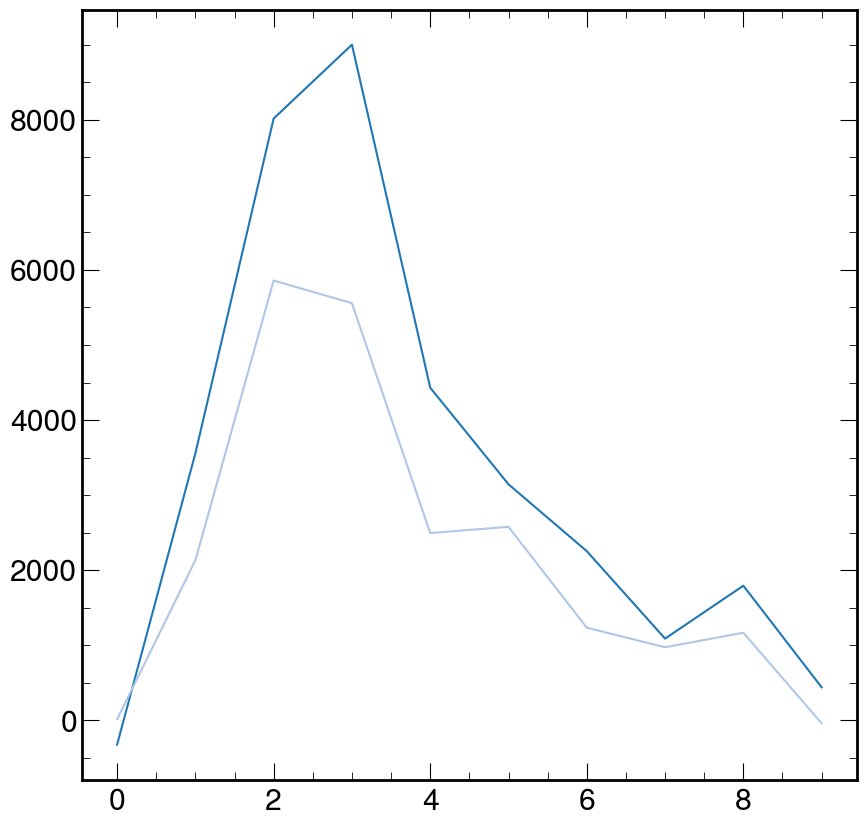

In [207]:
plt.plot(output_pythia[2])
plt.plot(output_herwig[2])

ValueError: operands could not be broadcast together with shapes (0,) (10,) 

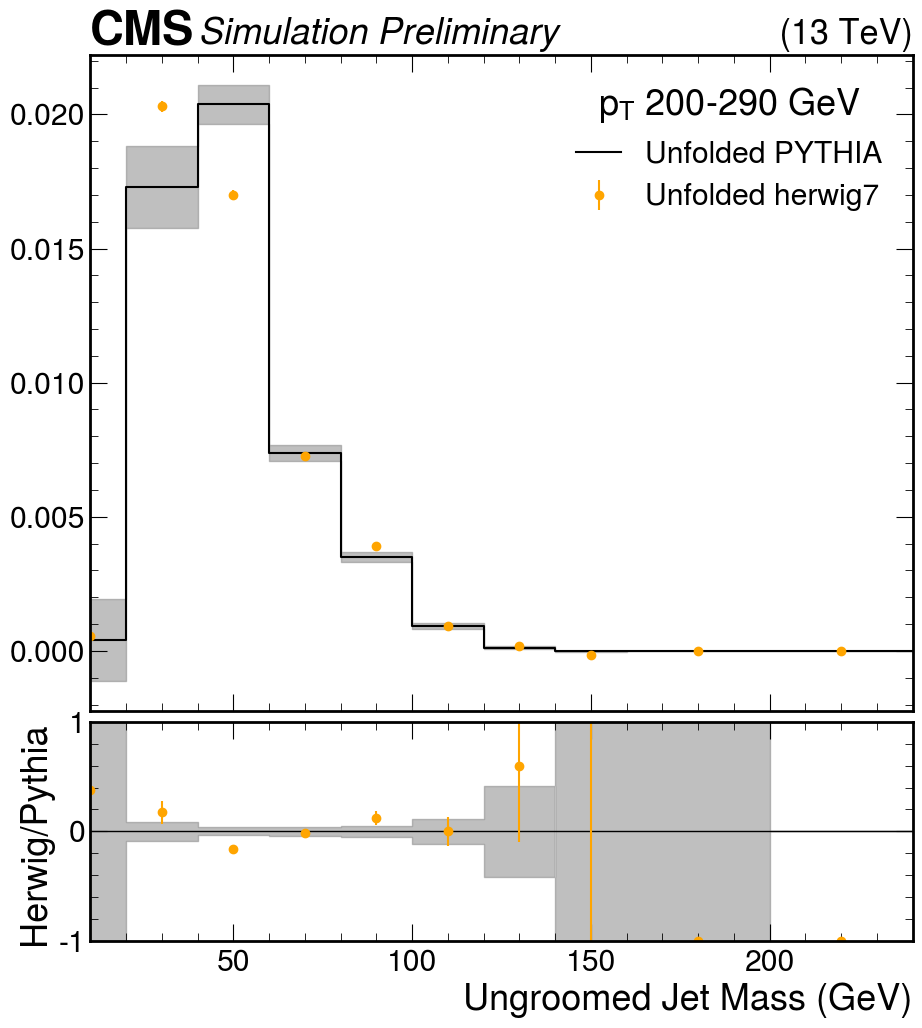

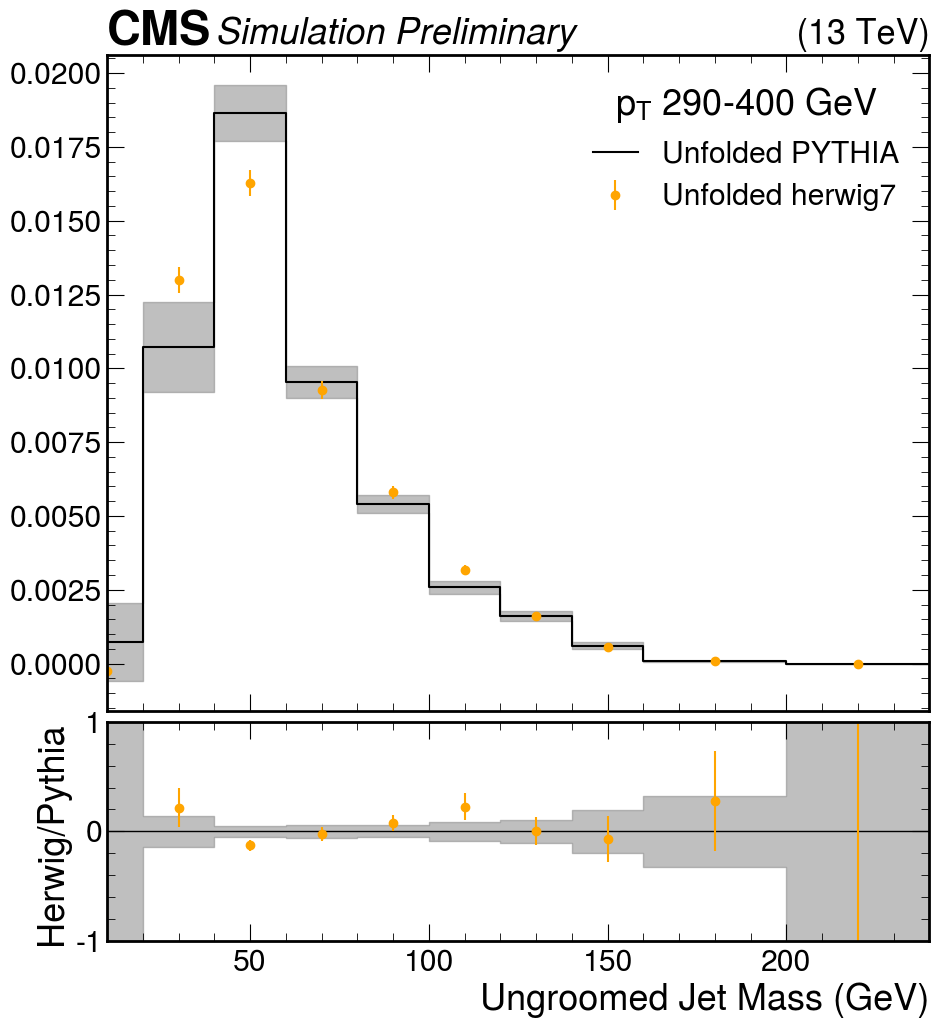

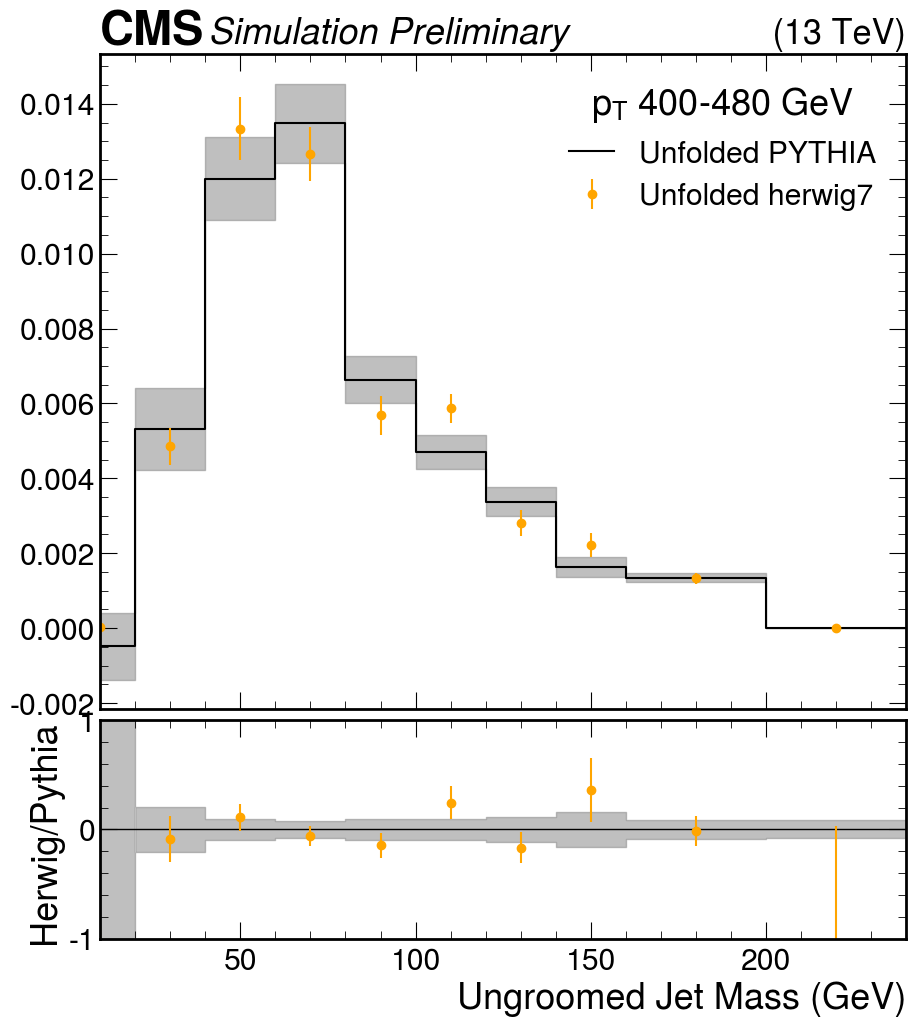

In [208]:
mgen_edge_mod = mgen_edge.copy()
mgen_edge_mod[-1] = 240
title_list = [ r"$p_T$ 200-290 GeV",  r"$p_T$ 290-400 GeV",  r"$p_T$ 400-480 GeV",  r"$p_T$ 480-$\infty$ GeV"]


for i in range(4):
    fig, (ax1, ax2) = make_comparison_plot(
            output_pythia[i]/mgen_width/output_pythia[i].sum(), unc_pythia[i]/mgen_width/output_pythia[i].sum(),
            output_herwig[i]/mgen_width/output_herwig[i].sum(), unc_herwig[i]/mgen_width/output_herwig[i].sum(),
            mgen_edge_mod
        )
    
    ax2.set_ylim(-1, 1)
    ax1.set_xlim(10,240)
    ax1.legend(title = title_list[i])
    if groomed:
        ax2.set_xlabel("Groomed Jet Mass (GeV)")

    else:
        ax2.set_xlabel("Ungroomed Jet Mass (GeV)")
    ax2.set_ylabel("Herwig/Pythia")
    hep.cms.label("Preliminary", ax = ax1)


In [209]:
 resp_matrix_4d.axes['mgen'].edges

array([    0.,    20.,    40.,    60.,    80.,   100.,   120.,   140.,
         160.,   200., 13000.])

In [210]:
widths

array([1.00e+01, 1.00e+01, 2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01,
       2.00e+01, 2.00e+01, 2.00e+01, 4.00e+01, 1.28e+04])

In [211]:
data_list = []
for ipt in range(4):
    edges = [1.00e+01, 1.00e+01, 2.00e+01, 2.00e+01, 2.00e+01, 2.00e+01,
       2.00e+01, 2.00e+01, 2.00e+01, 4.00e+01, 1.28e+04]
    y_data =  resp_matrix_4d[{'systematic':'nominal'}].project('ptgen', 'mgen')[ipt, :].values()
    
    y_data = y_data/y_data.sum()

    y2_data = unfolder.get_results()[0][ipt]
    y2_data = y2_data/y2_data.sum()
    up = unfolder.get_results()[1][ipt]
    down = unfolder_dn.get_results()[1][ipt]
    stat_unc_up = stat_unc[i]
    data_list.append([edges, y2_data, stat_unc_up, up, down, y_data])
    

IndexError: index 3 is out of bounds for axis 0 with size 3

In [212]:
markers = ['o', 's', 'D', '^', 'v']
ptbinsGen = ptgen_edge
ipt = 0 
for i in range(4):
    x_data = resp_matrix_4d.axes['mgen'].centers  
    widths = resp_matrix_4d.axes['mgen'].widths
    if not groomed:
        if i == 3:
            x_data = [5.0e+00, 1.5e+01, 40,  7.0e+01, 100,
       1.3e+02, 1.5e+02, 1.8e+02, 225]
#widths = resp_matrix_4d.axes['mgen'].widths
            widths = [10,10,40,20,40,20,20, 40, 12540]
        
    
    power_text = r'$\times 10^{{{}}}$'.format(i)
    pt_text = r'$p_T$ '+ str(ptbinsGen[ipt])[:-2]+'-'+str(ptbinsGen[ipt+1])[:-2] + ' GeV ' + power_text
    ipt = ipt + 1
    if i==0:
        plt.stairs(np.array(data_list[i][1][:-4])*(10**i), data_list[i][0][:-4], color = 'black' )
        plt.plot(x_data[:-4], np.array(data_list[i][1][:-4])*(10**i), color = 'black' , lw = 0, marker = markers[i], label = pt_text)
    elif i==1:
        plt.stairs(np.array(data_list[i][1][:-3])*(10**i), data_list[i][0][:-3], color = 'black' )
        plt.plot(x_data[:-3], np.array(data_list[i][1][:-3])*(10**i), color = 'black' , lw = 0, marker = markers[i], label = pt_text)
        
    else:    
        plt.stairs(np.array(data_list[i][1])*(10**i), data_list[i][0], color = 'black' )   
            
        plt.plot(x_data, np.array(data_list[i][1])*(10**i), color = 'black' , lw = 0, marker = markers[i], label = pt_text)
    plt.xlim(0,100)
    plt.yscale('log')
    plt.ylim(10**-5, 60)
    plt.xlim(20, 200)
    plt.ylim()
    widths[-1] = 20
    if groomed:
        #custom_text = 'Groomed'
        xlabel = "Groomed Jet Mass $m_{g}$ (GeV)"
        ylabel=r'$\frac{1}{d\sigma/dp_{T}} \, \frac{d^2 \sigma}{dm_{g} \, dp_{T}}$ (1/GeV)'
    else:
        #custom_text  = 'Ungroomed'
        xlabel = "Ungroomed Jet Mass $m_{u}$ (GeV)"
        ylabel=r'$\frac{1}{d\sigma/dp_{T}} \, \frac{d^2 \sigma}{dm_{u} \, dp_{T}} (1/GeV)$'
    plt.xlabel(xlabel)
    plt.ylabel( ylabel)
    
    sys_up = np.array(data_list[i][3])*10**i 
    sys_down = np.array(data_list[i][4])*10**i 
    tot_up = np.sqrt(np.array(sys_up)**2 + np.array(data_list[i][2])*10**i)
    tot_down = np.sqrt(np.array(sys_up)**2 + np.array(data_list[i][2])*10**i)

    if i ==0:
        plt.bar(x_data[:-4], # x
            2*np.array(data_list[i][2][:-4])*10**i, # heights
            #alpha=0.5, # half transparency
            bottom=(np.array(data_list[i][1][:-4])*(10**i)) - (np.array(data_list[i][2][:-4])*(10**i)), color='b',  width=widths[:-4], label='Stat. Unc.')
        print(np.array(data_list[i][2][:-4])*10**i)
        plt.bar(x_data[:-4], # x
            tot_up[:-4] + tot_down[:-4], # heights
            alpha=0.5, # half transparency
            bottom=(np.array(data_list[i][1][:-4])*(10**i)) - tot_down[:-4], color = 'cyan', width=widths[:-4], label='Total Unc')
    elif i ==1:
        idx = 3
        plt.bar(x_data[:-idx], # x
            2*np.array(data_list[i][2][:-idx])*10**i, # heights
            #alpha=0.5, # half transparency
            bottom=(np.array(data_list[i][1][:-idx])*(10**i)) - (np.array(data_list[i][2][:-idx])*(10**i)), color='b',  width=widths[:-idx], label='Stat. Unc.')
        print(np.array(data_list[i][2][:-idx])*10**i)
        plt.bar(x_data[:-idx], # x
            tot_up[:-idx] + tot_down[:-idx], # heights
            alpha=0.5, # half transparency
            bottom=(np.array(data_list[i][1][:-idx])*(10**i)) - tot_down[:-idx], color = 'cyan', width=widths[:-idx], label='Total Unc')
    else:
        plt.bar(x_data, # x
            2*np.array(data_list[i][2])*10**i, # heights
            #alpha=0.5, # half transparency
            bottom=(np.array(data_list[i][1])*(10**i)) - (np.array(data_list[i][2])*(10**i)), color='b',  width=widths, label='Stat. Unc.')
        print(np.array(data_list[i][2])*10**i)
        plt.bar(x_data, # x
            tot_up + tot_down, # heights
            alpha=0.5, # half transparency
            bottom=(np.array(data_list[i][1])*(10**i)) - tot_down, color = 'cyan', width=widths, label='Total Unc')
for i in range(4):  
    if i == 0:
        idx = 4
        plt.stairs(np.array(data_list[i][5][:-idx])*(10**i), data_list[i][0][:-idx], color = 'red', label = ' PYTHIA', lw = 2  )
    elif i == 1:
        idx = 3
        plt.stairs(np.array(data_list[i][5][:-idx])*(10**i), data_list[i][0][:-idx], color = 'red', label = ' PYTHIA', lw = 2  )
    else:

        plt.stairs(np.array(data_list[i][5][:])*(10**i), data_list[i][0][:], color = 'red', label = ' PYTHIA', lw = 2  )
handles, labels = plt.gca().get_legend_handles_labels()
        
handles.append(plt.Line2D([0], [0], color='none', label=custom_text))
handles.append(plt.Line2D([0], [0], color='none', label=custom_text))
labels.append(custom_text)

# Add legend with the custom entry
hep.cms.label("Preliminary", data = 1)
by_label = dict(zip(labels, handles))
leg = plt.legend(by_label.values(), by_label.keys(), fontsize = 12)

IndexError: list index out of range

In [107]:
resp_matrix_4d.project('ptgen', 'mgen').values()
pythia_gen_merged, _, _ = merge_bins(resp_matrix_4d.project('ptgen', 'mgen').values()[3], mgen_edge, merge_indices)

NameError: name 'merge_bins' is not defined

In [108]:
pythia_orig_dic = {}
for i in range(3):
    pythia_orig_dic[i] = resp_matrix_4d.project('ptgen', 'mgen').values()[i]
pythia_orig_dic[3] = pythia_gen_merged

NameError: name 'pythia_gen_merged' is not defined

In [109]:
if not groomed:
    with open("pythia_gen_ungroomed.pkl", "wb") as f:
        pkl.dump(pythia_orig_dic, f)
else:
    with open("pythia_gen_groomed.pkl", "wb") as f:
        pkl.dump(pythia_orig_dic, f)